Please upload 'Excel Sheet.xlsx' and 'Weather_2025_halfhourly.xlsx'


Saving Excel Sheet.xlsx to Excel Sheet.xlsx
Saving Weather_2025_halfhourly.xlsx to Weather_2025_halfhourly.xlsx
dd rows: 17518 | unique timestamps: 17518
system rows: 35040 | unique timestamps: 35036
weather rows: 26303 | unique timestamps: 26303

--- Annual heating demand per reference home (kWh/year) ---
24-hour notional (upper bound):    8,196 kWh
Realistic warm-up window:          2,875 kWh
SAP standard window (lower bound): 2,921 kWh

% of 24h notional demand that falls during surplus-wind half-hours: 65.7%

Saved: Merged_2025_with_HeatingDemand.xlsx


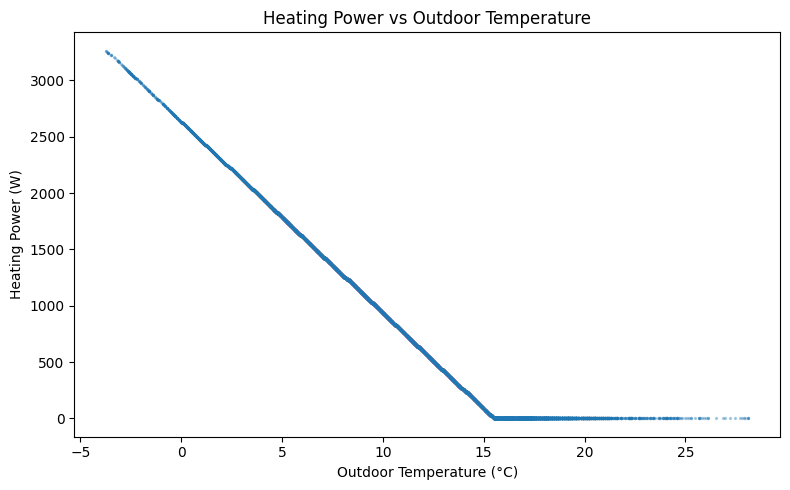

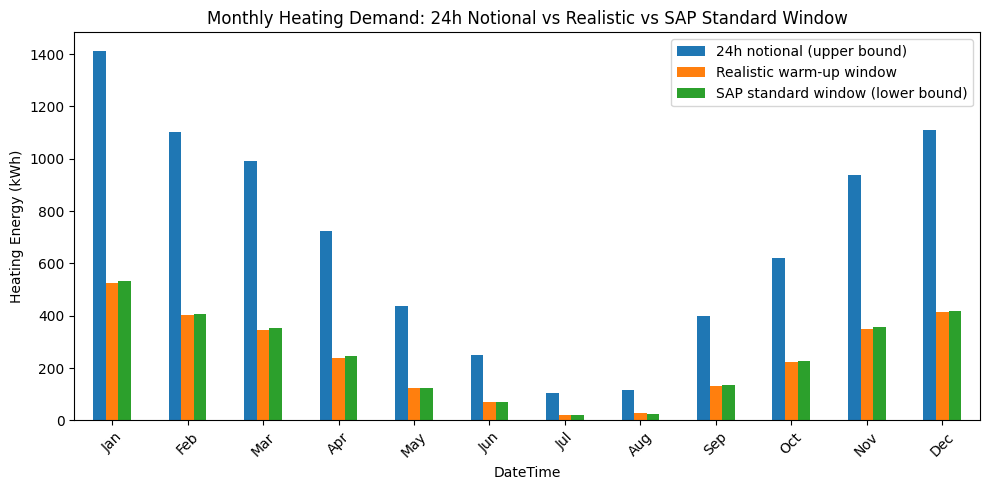

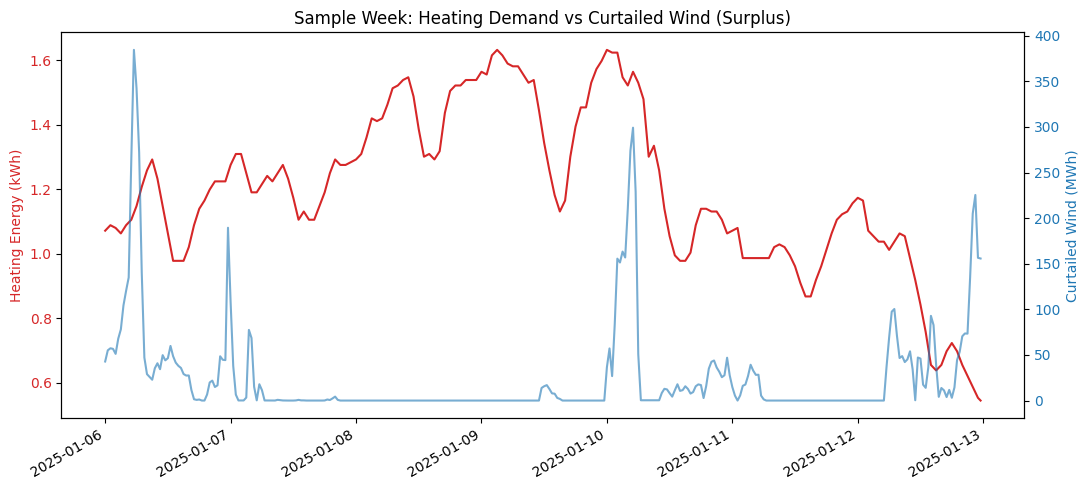

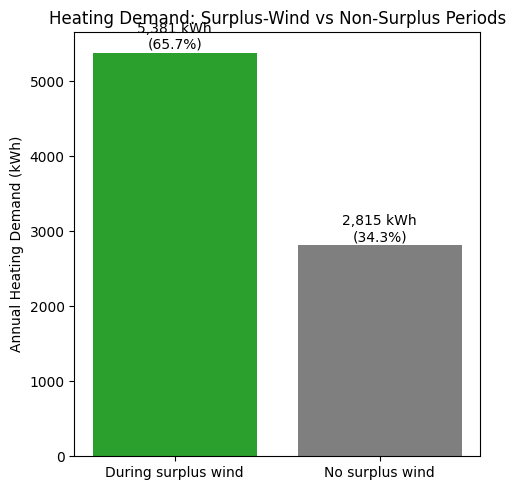

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! All files downloaded.

===== DIAGNOSTIC =====
dd rows: 17518 | unique timestamps: 17518
system rows: 35040 | unique timestamps: 35036
weather rows: 26303 | unique timestamps: 26303


In [ ]:

# ============================================================
# Heating Demand Analysis - extends the original merge script
# Run this in Google Colab
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# PART 1 — YOUR EXISTING CODE (unchanged)
# This is exactly what you had before. Nothing below this
# section needs to change.
# ============================================================

print("Please upload 'Excel Sheet.xlsx' and 'Weather_2025_halfhourly.xlsx'")
uploaded = files.upload()

# Read Dispatch Down
dd = pd.read_excel(
    "Excel Sheet.xlsx",
    sheet_name="DD_2025"
)
dd = dd[["HH_TIMESTAMP", "Sum of DD_MWH"]]
dd.columns = ["DateTime", "Dispatch_Down_MWh"]
dd = dd.groupby("DateTime", as_index=False)["Dispatch_Down_MWh"].sum()

# Read System Data
system = pd.read_excel(
    "Excel Sheet.xlsx",
    sheet_name="System_2025"
)
system = system[[
    "DateTime",
    "NI Demand",
    "NI Wind Generation"
]]

# Read Weather Data
weather = pd.read_excel("Weather_2025_halfhourly.xlsx")

# Find columns by keyword instead of exact name (avoids ° encoding issues)
datetime_col = [c for c in weather.columns if 'DateTime' in c][0]
temp_col = [c for c in weather.columns if 'temperature' in c.lower()][0]
wind_col = [c for c in weather.columns if 'wind_speed' in c.lower()][0]
humidity_col = [c for c in weather.columns if 'humidity' in c.lower()][0]

weather = weather[[datetime_col, temp_col, wind_col, humidity_col]]
weather.columns = [
    "DateTime",
    "Temperature",
    "Wind_Speed",
    "Relative_Humidity"
]
# NOTE: the old Heating_Demand_kWh column from the weather file is
# deliberately dropped here — we recalculate it properly below using
# the confirmed 170 W/K coefficient instead of the old assumed figure.

# Convert to datetime
dd["DateTime"] = pd.to_datetime(dd["DateTime"])
system["DateTime"] = pd.to_datetime(system["DateTime"])
weather["DateTime"] = pd.to_datetime(weather["DateTime"])

print("dd rows:", len(dd), "| unique timestamps:", dd['DateTime'].nunique())
print("system rows:", len(system), "| unique timestamps:", system['DateTime'].nunique())
print("weather rows:", len(weather), "| unique timestamps:", weather['DateTime'].nunique())

# Merge
merged = dd.merge(system, on="DateTime")
merged = merged.merge(weather, on="DateTime")


# ============================================================
# PART 2 — NEW CODE STARTS HERE
# Everything from this point on is new: heating demand
# calculations, the Dispatch_Down link, and plots.
# ============================================================

# --- Step 2.1: keep only 2025 data ---
# (the weather file can contain extra months beyond 2025 - this
# makes sure annual totals aren't inflated)
merged = merged[
    (merged["DateTime"] >= "2025-01-01") & (merged["DateTime"] < "2026-01-01")
].reset_index(drop=True)

# --- Step 2.2: heating power and energy, using the confirmed coefficient ---
# 170 W/K is the Heat Transfer Coefficient from Andy's SAP assessment
# of an NIHE mid-terrace home. 15.5°C is the UK-standard base/balance-point
# temperature (Met Office / CIBSE convention).
HTC = 170          # W/K
BASE_TEMP = 15.5   # °C

degree = (BASE_TEMP - merged["Temperature"]).clip(lower=0)          # °C below base temp
merged["Heating_Power_W"] = HTC * degree                            # instantaneous power (W)
merged["Heating_Energy_24h_kWh"] = merged["Heating_Power_W"] * 0.5 / 1000  # energy per half-hour (kWh)
# ^ this is the "24-hour notional" / upper-bound scenario: heat delivered
#   at any time, banked by thermal mass or storage (hot water, hot bricks).

# --- Step 2.3: SAP standard heating window (lower bound) ---
# Direct heating only during 7-9am and 4-11pm
hour = merged["DateTime"].dt.hour + merged["DateTime"].dt.minute / 60
sap_mask = ((hour >= 7) & (hour < 9)) | ((hour >= 16) & (hour < 23))
merged["Heating_Energy_SAP_kWh"] = merged["Heating_Energy_24h_kWh"].where(sap_mask, 0)

# --- Step 2.4: realistic warm-up window (alternative lower bound) ---
# 6:30-8:30am and 3:30-10:30pm, allowing lead time for the home to warm up
realistic_mask = ((hour >= 6.5) & (hour < 8.5)) | ((hour >= 15.5) & (hour < 22.5))
merged["Heating_Energy_Realistic_kWh"] = merged["Heating_Energy_24h_kWh"].where(realistic_mask, 0)

# --- Step 2.5: link to curtailed/surplus wind (Dispatch_Down) ---
merged["Surplus_Wind"] = merged["Dispatch_Down_MWh"] > 0

# --- Step 2.6: print annual summary ---
annual_24h = merged["Heating_Energy_24h_kWh"].sum()
annual_realistic = merged["Heating_Energy_Realistic_kWh"].sum()
annual_sap = merged["Heating_Energy_SAP_kWh"].sum()
demand_in_surplus = merged.loc[merged["Surplus_Wind"], "Heating_Energy_24h_kWh"].sum()
pct_overlap = 100 * demand_in_surplus / annual_24h

print("\n--- Annual heating demand per reference home (kWh/year) ---")
print(f"24-hour notional (upper bound):    {annual_24h:,.0f} kWh")
print(f"Realistic warm-up window:          {annual_realistic:,.0f} kWh")
print(f"SAP standard window (lower bound): {annual_sap:,.0f} kWh")
print(f"\n% of 24h notional demand that falls during surplus-wind half-hours: {pct_overlap:.1f}%")

# --- Step 2.7: save the extended dataset ---
output_file = "Merged_2025_with_HeatingDemand.xlsx"
merged.to_excel(output_file, index=False)
print(f"\nSaved: {output_file}")

# ============================================================
# PART 3 — PLOTS
# ============================================================

# Plot 1: Heating power vs outdoor temperature
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(merged["Temperature"], merged["Heating_Power_W"], s=2, alpha=0.3)
ax.set_xlabel("Outdoor Temperature (°C)")
ax.set_ylabel("Heating Power (W)")
ax.set_title("Heating Power vs Outdoor Temperature")
fig.tight_layout()
fig.savefig("plot1_power_vs_temperature.png", dpi=150)
plt.show()

# Plot 2: Monthly comparison of the three demand scenarios
monthly = merged.set_index("DateTime")[
    ["Heating_Energy_24h_kWh", "Heating_Energy_Realistic_kWh", "Heating_Energy_SAP_kWh"]
].resample("ME").sum()

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind="bar", ax=ax)
ax.set_ylabel("Heating Energy (kWh)")
ax.set_title("Monthly Heating Demand: 24h Notional vs Realistic vs SAP Standard Window")
ax.set_xticklabels([d.strftime("%b") for d in monthly.index], rotation=45)
ax.legend(["24h notional (upper bound)", "Realistic warm-up window", "SAP standard window (lower bound)"])
fig.tight_layout()
fig.savefig("plot2_monthly_comparison.png", dpi=150)
plt.show()

# Plot 3: Sample week — heating demand vs curtailed wind
sample = merged[(merged["DateTime"] >= "2025-01-06") & (merged["DateTime"] < "2025-01-13")]
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(sample["DateTime"], sample["Heating_Energy_24h_kWh"], color="tab:red", label="Heating Energy (kWh)")
ax1.set_ylabel("Heating Energy (kWh)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax2 = ax1.twinx()
ax2.plot(sample["DateTime"], sample["Dispatch_Down_MWh"], color="tab:blue", alpha=0.6, label="Curtailed Wind (MWh)")
ax2.set_ylabel("Curtailed Wind (MWh)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_title("Sample Week: Heating Demand vs Curtailed Wind (Surplus)")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("plot3_sample_week.png", dpi=150)
plt.show()

# Plot 4: Overlap summary — demand during surplus vs non-surplus periods
demand_not_surplus = annual_24h - demand_in_surplus
fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(
    ["During surplus wind", "No surplus wind"],
    [demand_in_surplus, demand_not_surplus],
    color=["tab:green", "tab:gray"]
)
ax.set_ylabel("Annual Heating Demand (kWh)")
ax.set_title("Heating Demand: Surplus-Wind vs Non-Surplus Periods")
for i, v in enumerate([demand_in_surplus, demand_not_surplus]):
    ax.text(i, v + 50, f"{v:,.0f} kWh\n({100*v/annual_24h:.1f}%)", ha="center")
fig.tight_layout()
fig.savefig("plot4_surplus_overlap.png", dpi=150)
plt.show()

# --- Download everything ---
files.download(output_file)
files.download("plot1_power_vs_temperature.png")
files.download("plot2_monthly_comparison.png")
files.download("plot3_sample_week.png")
files.download("plot4_surplus_overlap.png")

print("\nDone! All files downloaded.")

print()
print("===== DIAGNOSTIC =====")
print("dd rows:", len(dd), "| unique timestamps:", dd['DateTime'].nunique())
print("system rows:", len(system), "| unique timestamps:", system['DateTime'].nunique())
print("weather rows:", len(weather), "| unique timestamps:", weather['DateTime'].nunique())

Upload: Merged_2025_NI_Scaled_Heating_Final.xlsx


Saving Merged_2025_NI_Scaled_Heating_Final.xlsx to Merged_2025_NI_Scaled_Heating_Final.xlsx

File loaded successfully.
Rows: 17525

Columns:
0 : DateTime
1 : Dispatch_Down_MWh
2 : Dispatch_Down_KWh
3 : NI Demand
4 : NI Wind Generation
5 : Temperature
6 : Wind_Speed
7 : Relative_Humidity
8 : Heating_Power_W
9 : Heating_Energy_24h_kWh
10 : Heating_Energy_SAP_kWh
11 : Heating_Energy_Realistic_kWh
12 : Surplus_Wind
13 : Heating _Energy _NI_SAP_kWh
14 : Matched_Heating_kWh
15 : Unmet_Heating_kWh
16 : Unused_Dispatch_Down_kWh

Number of half-hour observations: 17520

INPUT DATA CHECK
Annual Dispatch Down: 2317.72 GWh
Annual SAP Heating Demand: 2459.33 GWh

2-hour storage capacity: 5,259,314.18 kWh

4-hour storage capacity: 10,311,118.01 kWh


FLEXIBILITY RESULTS
              Scenario  Heating_Demand_GWh  Matched_Heating_GWh  Heating_Coverage_percent
            No storage             2459.33               355.45                     14.45
2-hour thermal storage             2459.33           

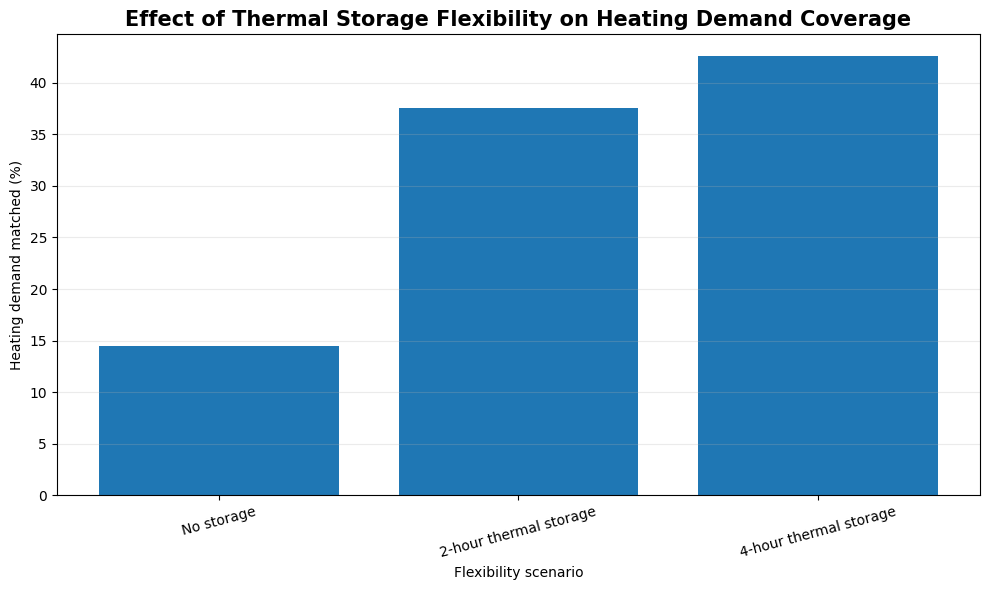

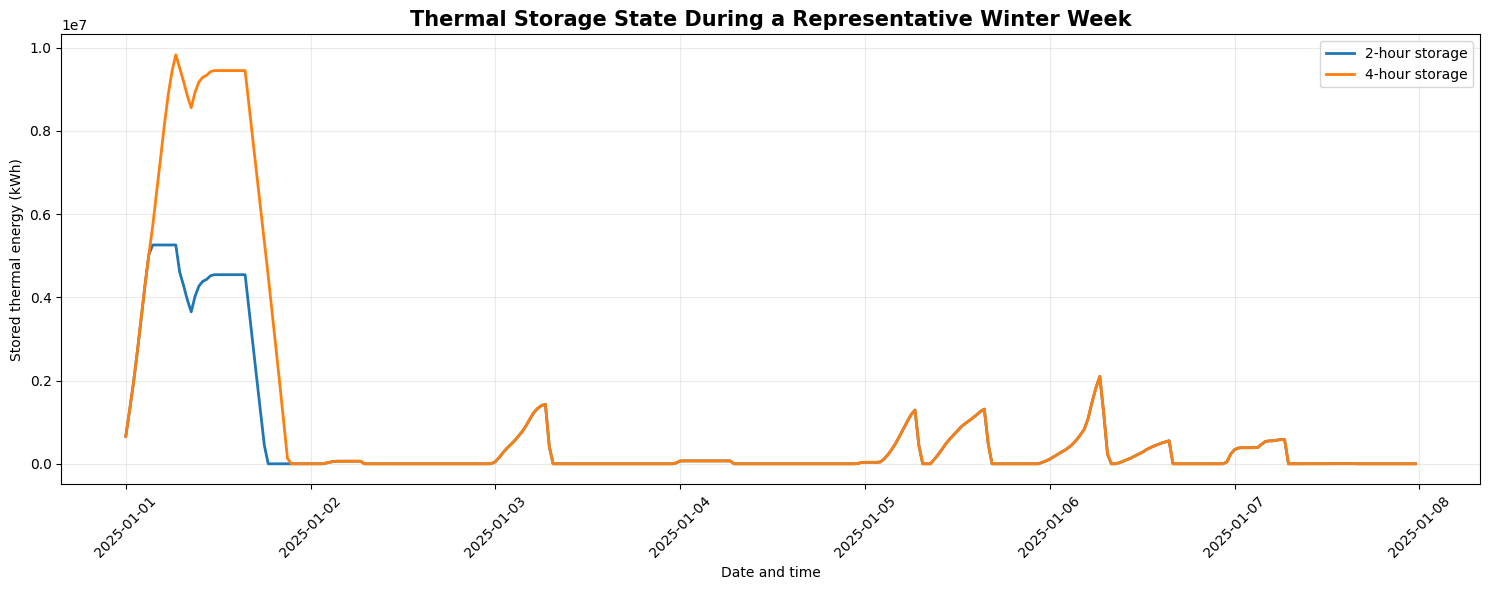

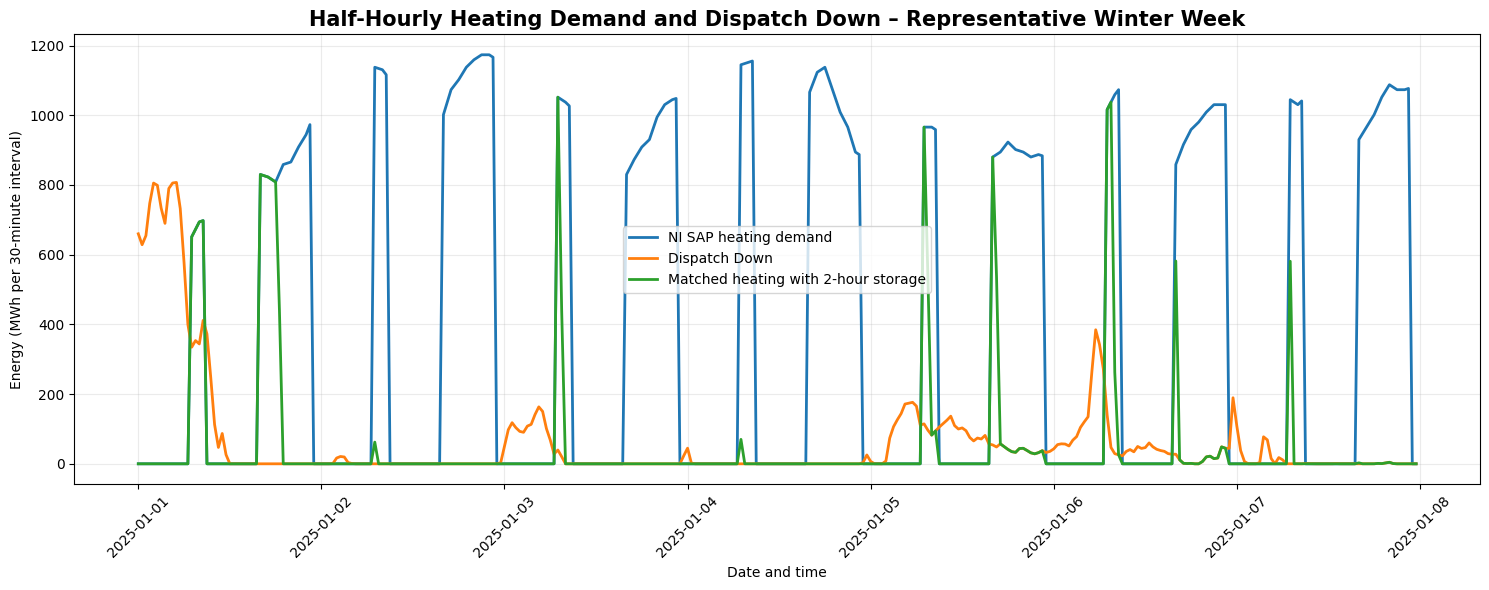

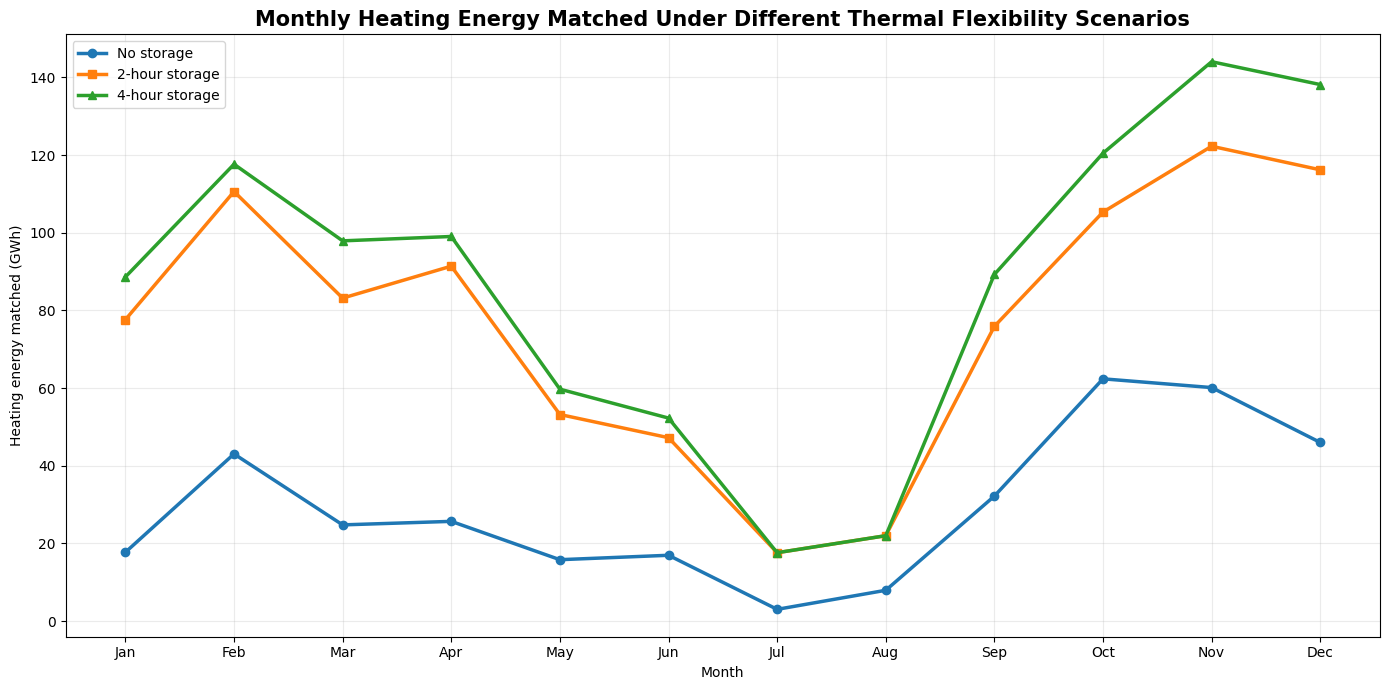


FILES CREATED
NI_Thermal_Storage_Analysis_2025.xlsx
Figure_Thermal_Storage_Comparison.png
Figure_Thermal_Storage_Winter_Week.png
Figure_HalfHourly_Heating_Dispatch_2h.png
Figure_Monthly_Thermal_Flexibility.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FLEXIBLE THERMAL STORAGE ANALYSIS
# Northern Ireland Residential Heating + Dispatch Down
# 30-minute resolution
#
# Scenarios:
#   1. No storage
#   2. 2-hour thermal storage
#   3. 4-hour thermal storage
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files


# ============================================================
# 1. UPLOAD YOUR MASTER EXCEL FILE
# ============================================================

print("Upload: Merged_2025_NI_Scaled_Heating_Final.xlsx")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_excel(filename, sheet_name="Sheet1")

print("\nFile loaded successfully.")
print("Rows:", len(df))

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)


# ============================================================
# 2. CLEAN AND SORT DATA
# ============================================================

df["DateTime"] = pd.to_datetime(df["DateTime"])

df = df.sort_values("DateTime").reset_index(drop=True)


# Keep the actual 2025 half-hour records
# Your master dataset should contain 17,520 records.
df = df.iloc[:17520].copy()

print("\nNumber of half-hour observations:", len(df))


# ============================================================
# 3. DEFINE THE INPUT COLUMNS
# ============================================================

dispatch_col = "Dispatch_Down_KWh"

heating_col = "Heating _Energy _NI_SAP_kWh"


# Check that columns exist
if dispatch_col not in df.columns:
    raise ValueError(
        f"Column not found: {dispatch_col}"
    )

if heating_col not in df.columns:
    raise ValueError(
        f"Column not found: {heating_col}"
    )


# Replace missing values with zero
df[dispatch_col] = df[dispatch_col].fillna(0)

df[heating_col] = df[heating_col].fillna(0)


# ============================================================
# 4. BASIC INPUT CHECK
# ============================================================

print("\n============================================")
print("INPUT DATA CHECK")
print("============================================")

print(
    "Annual Dispatch Down:",
    f"{df[dispatch_col].sum()/1e6:.2f} GWh"
)

print(
    "Annual SAP Heating Demand:",
    f"{df[heating_col].sum()/1e6:.2f} GWh"
)


# ============================================================
# 5. CURRENT NO-STORAGE CASE
# ============================================================
#
# At each half-hour:
#
# Matched heating =
# minimum(heating demand, dispatch down)
#
# This is your current direct matching calculation.
# ============================================================

df["Matched_NoStorage_kWh"] = np.minimum(
    df[heating_col],
    df[dispatch_col]
)

df["Unmet_NoStorage_kWh"] = (
    df[heating_col]
    - df["Matched_NoStorage_kWh"]
)


# ============================================================
# 6. FUNCTION FOR THERMAL STORAGE SCENARIO
# ============================================================
#
# storage_hours = 2 or 4
#
# Storage capacity is based on the maximum rolling heating
# requirement over the specified number of hours.
#
# Example:
#
# 2-hour storage
# = capacity sufficient to supply approximately
#   2 hours of modelled heating demand.
#
# The simulation runs chronologically.
# Dispatch Down can charge the store.
# Heating demand can discharge the store.
#
# No energy can be used twice.
# ============================================================

def simulate_storage(data, storage_hours):

    timestep_hours = 0.5

    # Number of half-hour intervals
    n_steps = int(storage_hours / timestep_hours)

    # --------------------------------------------------------
    # Calculate rolling heating demand
    # --------------------------------------------------------

    rolling_demand = (
        data[heating_col]
        .rolling(
            window=n_steps,
            min_periods=1
        )
        .sum()
    )

    # Storage capacity
    storage_capacity = rolling_demand.max()

    print(
        f"\n{storage_hours}-hour storage capacity: "
        f"{storage_capacity:,.2f} kWh"
    )

    # --------------------------------------------------------
    # Arrays
    # --------------------------------------------------------

    storage = np.zeros(len(data))

    charged = np.zeros(len(data))

    discharged = np.zeros(len(data))

    matched = np.zeros(len(data))

    unmet = np.zeros(len(data))

    unused_dispatch = np.zeros(len(data))

    # --------------------------------------------------------
    # Chronological simulation
    # --------------------------------------------------------

    current_storage = 0.0

    for i in range(len(data)):

        dispatch = max(
            0,
            data.iloc[i][dispatch_col]
        )

        demand = max(
            0,
            data.iloc[i][heating_col]
        )

        # ----------------------------------------------------
        # 1. Charge storage from Dispatch Down
        # ----------------------------------------------------

        available_storage_space = (
            storage_capacity
            - current_storage
        )

        charge = min(
            dispatch,
            available_storage_space
        )

        current_storage += charge

        remaining_dispatch = (
            dispatch - charge
        )

        # ----------------------------------------------------
        # 2. Meet heating demand from storage
        # ----------------------------------------------------

        discharge = min(
            demand,
            current_storage
        )

        current_storage -= discharge

        # ----------------------------------------------------
        # 3. Any remaining current dispatch can directly
        #    meet remaining heating demand
        # ----------------------------------------------------

        remaining_demand = (
            demand - discharge
        )

        direct_match = min(
            remaining_demand,
            remaining_dispatch
        )

        remaining_dispatch -= direct_match

        # ----------------------------------------------------
        # 4. Final matched heating
        # ----------------------------------------------------

        total_matched = (
            discharge + direct_match
        )

        remaining_unmet = (
            demand - total_matched
        )

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        storage[i] = current_storage

        charged[i] = charge

        discharged[i] = discharge

        matched[i] = total_matched

        unmet[i] = remaining_unmet

        unused_dispatch[i] = remaining_dispatch

    return {
        "capacity": storage_capacity,
        "storage": storage,
        "charged": charged,
        "discharged": discharged,
        "matched": matched,
        "unmet": unmet,
        "unused": unused_dispatch
    }


# ============================================================
# 7. RUN 2-HOUR STORAGE
# ============================================================

result_2h = simulate_storage(
    df,
    storage_hours=2
)


# ============================================================
# 8. RUN 4-HOUR STORAGE
# ============================================================

result_4h = simulate_storage(
    df,
    storage_hours=4
)


# ============================================================
# 9. ADD RESULTS TO DATAFRAME
# ============================================================

df["Storage_2h_kWh"] = result_2h["storage"]

df["Charged_2h_kWh"] = result_2h["charged"]

df["Discharged_2h_kWh"] = result_2h["discharged"]

df["Matched_2h_kWh"] = result_2h["matched"]

df["Unmet_2h_kWh"] = result_2h["unmet"]

df["Unused_Dispatch_2h_kWh"] = result_2h["unused"]


df["Storage_4h_kWh"] = result_4h["storage"]

df["Charged_4h_kWh"] = result_4h["charged"]

df["Discharged_4h_kWh"] = result_4h["discharged"]

df["Matched_4h_kWh"] = result_4h["matched"]

df["Unmet_4h_kWh"] = result_4h["unmet"]

df["Unused_Dispatch_4h_kWh"] = result_4h["unused"]


# ============================================================
# 10. CALCULATE ANNUAL RESULTS
# ============================================================

annual_heating = df[heating_col].sum()

matched_no = df["Matched_NoStorage_kWh"].sum()

matched_2 = df["Matched_2h_kWh"].sum()

matched_4 = df["Matched_4h_kWh"].sum()


coverage_no = (
    matched_no / annual_heating * 100
)

coverage_2 = (
    matched_2 / annual_heating * 100
)

coverage_4 = (
    matched_4 / annual_heating * 100
)


# ============================================================
# 11. RESULTS TABLE
# ============================================================

results = pd.DataFrame({

    "Scenario": [
        "No storage",
        "2-hour thermal storage",
        "4-hour thermal storage"
    ],

    "Heating_Demand_GWh": [
        annual_heating / 1e6,
        annual_heating / 1e6,
        annual_heating / 1e6
    ],

    "Matched_Heating_GWh": [
        matched_no / 1e6,
        matched_2 / 1e6,
        matched_4 / 1e6
    ],

    "Heating_Coverage_percent": [
        coverage_no,
        coverage_2,
        coverage_4
    ]
})


print("\n")
print("============================================")
print("FLEXIBILITY RESULTS")
print("============================================")

print(
    results.round(2).to_string(index=False)
)


# ============================================================
# 12. IMPROVEMENT RELATIVE TO NO STORAGE
# ============================================================

improvement_2 = coverage_2 - coverage_no

improvement_4 = coverage_4 - coverage_no

print("\n============================================")
print("IMPROVEMENT")
print("============================================")

print(
    f"2-hour storage improvement: "
    f"{improvement_2:.2f} percentage points"
)

print(
    f"4-hour storage improvement: "
    f"{improvement_4:.2f} percentage points"
)


# ============================================================
# 13. FIGURE 1 — STORAGE SCENARIO COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results["Scenario"],
    results["Heating_Coverage_percent"]
)

plt.ylabel(
    "Heating demand matched (%)"
)

plt.xlabel(
    "Flexibility scenario"
)

plt.title(
    "Effect of Thermal Storage Flexibility on Heating Demand Coverage",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

figure1 = (
    "Figure_Thermal_Storage_Comparison.png"
)

plt.savefig(
    figure1,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. FIGURE 2 — STORAGE STATE FOR A WINTER WEEK
# ============================================================

# Select first week of January
start_date = pd.Timestamp("2025-01-01")
end_date = pd.Timestamp("2025-01-08")

week = df[
    (df["DateTime"] >= start_date) &
    (df["DateTime"] < end_date)
].copy()


plt.figure(figsize=(15, 6))

plt.plot(
    week["DateTime"],
    week["Storage_2h_kWh"],
    linewidth=2,
    label="2-hour storage"
)

plt.plot(
    week["DateTime"],
    week["Storage_4h_kWh"],
    linewidth=2,
    label="4-hour storage"
)

plt.ylabel(
    "Stored thermal energy (kWh)"
)

plt.xlabel(
    "Date and time"
)

plt.title(
    "Thermal Storage State During a Representative Winter Week",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

figure2 = (
    "Figure_Thermal_Storage_Winter_Week.png"
)

plt.savefig(
    figure2,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. FIGURE 3 — HALF-HOURLY HEATING VS DISPATCH
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    week["DateTime"],
    week[heating_col] / 1000,
    linewidth=2,
    label="NI SAP heating demand"
)

plt.plot(
    week["DateTime"],
    week[dispatch_col] / 1000,
    linewidth=2,
    label="Dispatch Down"
)

plt.plot(
    week["DateTime"],
    week["Matched_2h_kWh"] / 1000,
    linewidth=2,
    label="Matched heating with 2-hour storage"
)

plt.ylabel(
    "Energy (MWh per 30-minute interval)"
)

plt.xlabel(
    "Date and time"
)

plt.title(
    "Half-Hourly Heating Demand and Dispatch Down – "
    "Representative Winter Week",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

figure3 = (
    "Figure_HalfHourly_Heating_Dispatch_2h.png"
)

plt.savefig(
    figure3,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. MONTHLY STORAGE COMPARISON
# ============================================================

df["Month"] = df["DateTime"].dt.month

monthly = df.groupby("Month").agg({

    heating_col: "sum",

    "Matched_NoStorage_kWh": "sum",

    "Matched_2h_kWh": "sum",

    "Matched_4h_kWh": "sum"

})

monthly.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

monthly_gwh = monthly / 1e6


# ============================================================
# 17. FIGURE 4 — MONTHLY FLEXIBILITY COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

x = np.arange(12)

plt.plot(
    x,
    monthly_gwh["Matched_NoStorage_kWh"],
    marker="o",
    linewidth=2.5,
    label="No storage"
)

plt.plot(
    x,
    monthly_gwh["Matched_2h_kWh"],
    marker="s",
    linewidth=2.5,
    label="2-hour storage"
)

plt.plot(
    x,
    monthly_gwh["Matched_4h_kWh"],
    marker="^",
    linewidth=2.5,
    label="4-hour storage"
)

plt.xticks(
    x,
    monthly.index
)

plt.xlabel("Month")

plt.ylabel(
    "Heating energy matched (GWh)"
)

plt.title(
    "Monthly Heating Energy Matched Under Different "
    "Thermal Flexibility Scenarios",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

figure4 = (
    "Figure_Monthly_Thermal_Flexibility.png"
)

plt.savefig(
    figure4,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. SAVE COMPLETE RESULTS TO EXCEL
# ============================================================

output_excel = (
    "NI_Thermal_Storage_Analysis_2025.xlsx"
)

with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Half_Hourly_Results",
        index=False
    )

    results.to_excel(
        writer,
        sheet_name="Scenario_Summary",
        index=False
    )

    monthly_gwh.to_excel(
        writer,
        sheet_name="Monthly_Results"
    )


# ============================================================
# 19. DOWNLOAD FILES
# ============================================================

print("\n============================================")
print("FILES CREATED")
print("============================================")

print(output_excel)
print(figure1)
print(figure2)
print(figure3)
print(figure4)


files.download(output_excel)
files.download(figure1)
files.download(figure2)
files.download(figure3)
files.download(figure4)

NI HEATING FLEXIBILITY ANALYSIS - 2025

Upload your master Excel file:


Saving Merged_2025_NI_Scaled_Heating_Final.xlsx to Merged_2025_NI_Scaled_Heating_Final (3).xlsx

File uploaded:
Merged_2025_NI_Scaled_Heating_Final (3).xlsx

Sheets found:
['Sheet3', 'Sheet1']

DATA TABLE FOUND
Sheet: Sheet1
Header row: 1

Columns found in Excel:
0 : DateTime
1 : Dispatch_Down_MWh
2 : Dispatch_Down_KWh
3 : NI Demand
4 : NI Wind Generation
5 : Temperature
6 : Wind_Speed
7 : Relative_Humidity
8 : Heating_Power_W
9 : Heating_Energy_24h_kWh
10 : Heating_Energy_SAP_kWh
11 : Heating_Energy_Realistic_kWh
12 : Surplus_Wind
13 : Heating _Energy _NI_SAP_kWh
14 : Matched_Heating_kWh
15 : Unmet_Heating_kWh
16 : Unused_Dispatch_Down_kWh

COLUMN IDENTIFICATION
DateTime column:
DateTime

Dispatch Down column:
Dispatch_Down_MWh

NI SAP Heating column:
Heating _Energy _NI_SAP_kWh

DATA VALIDATION
Number of records: 17520
First timestamp: 2025-01-01 00:00:00
Last timestamp: 2025-12-31 23:30:00

Time interval distribution:
DateTime
0 days 00:30:00    17516
0 days 00:00:00        2
0 days

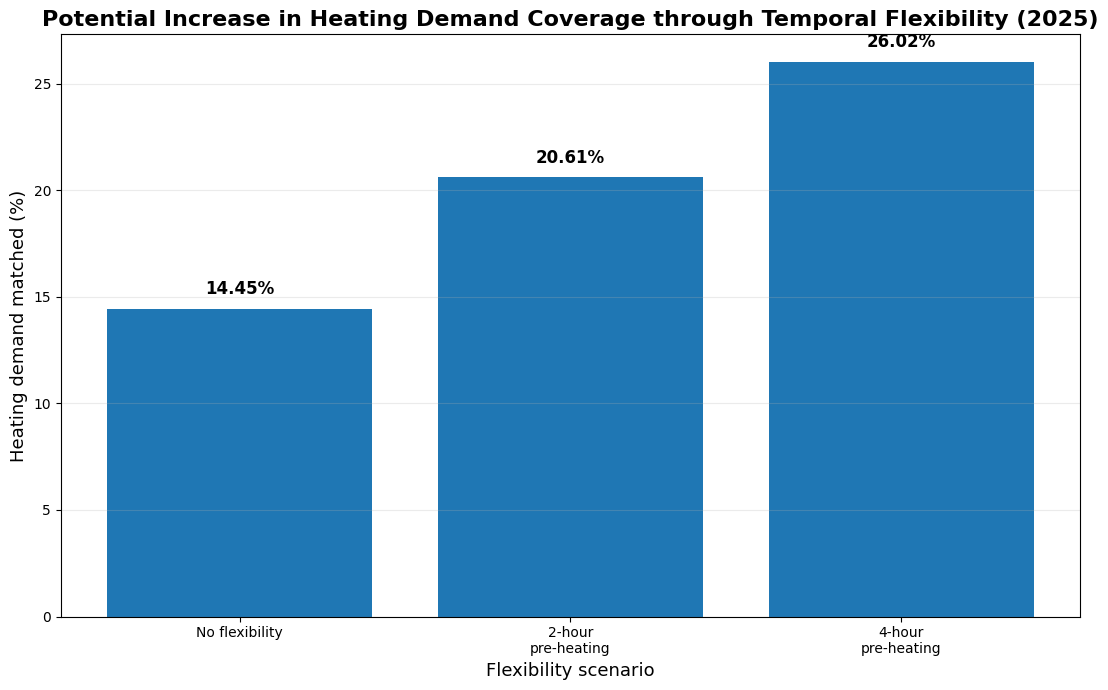

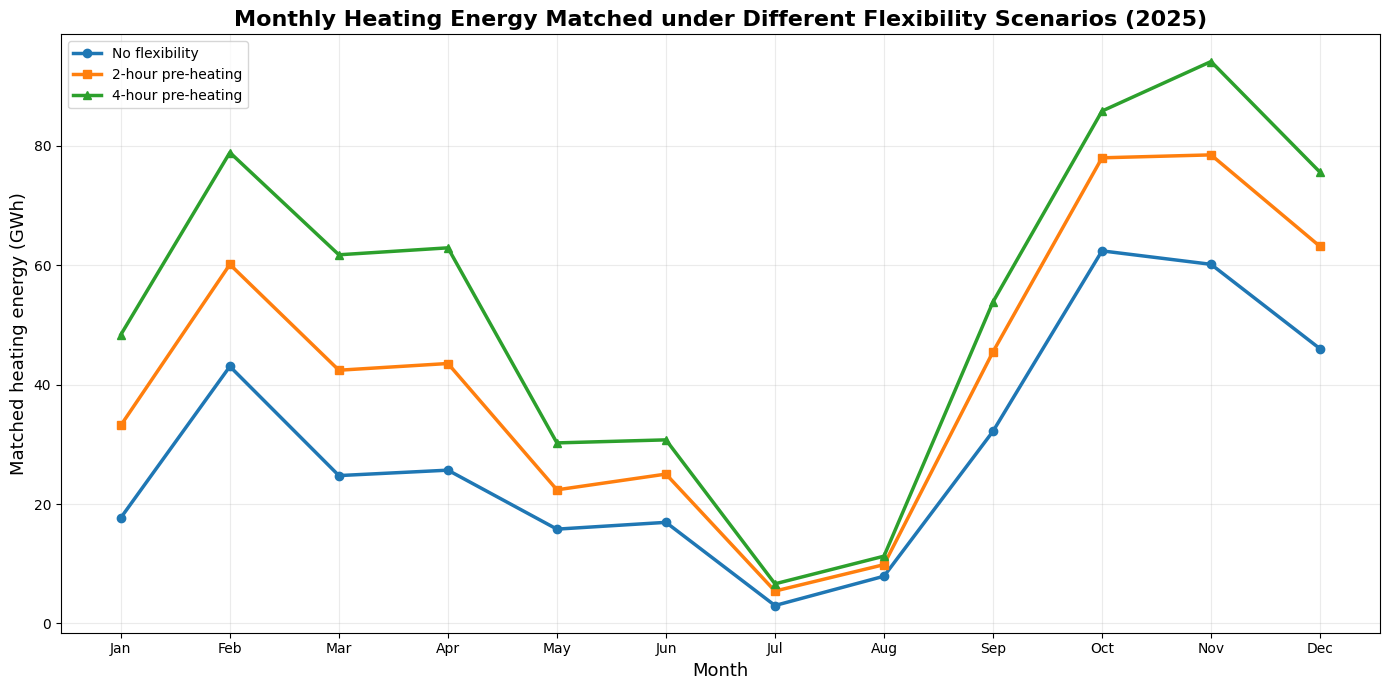

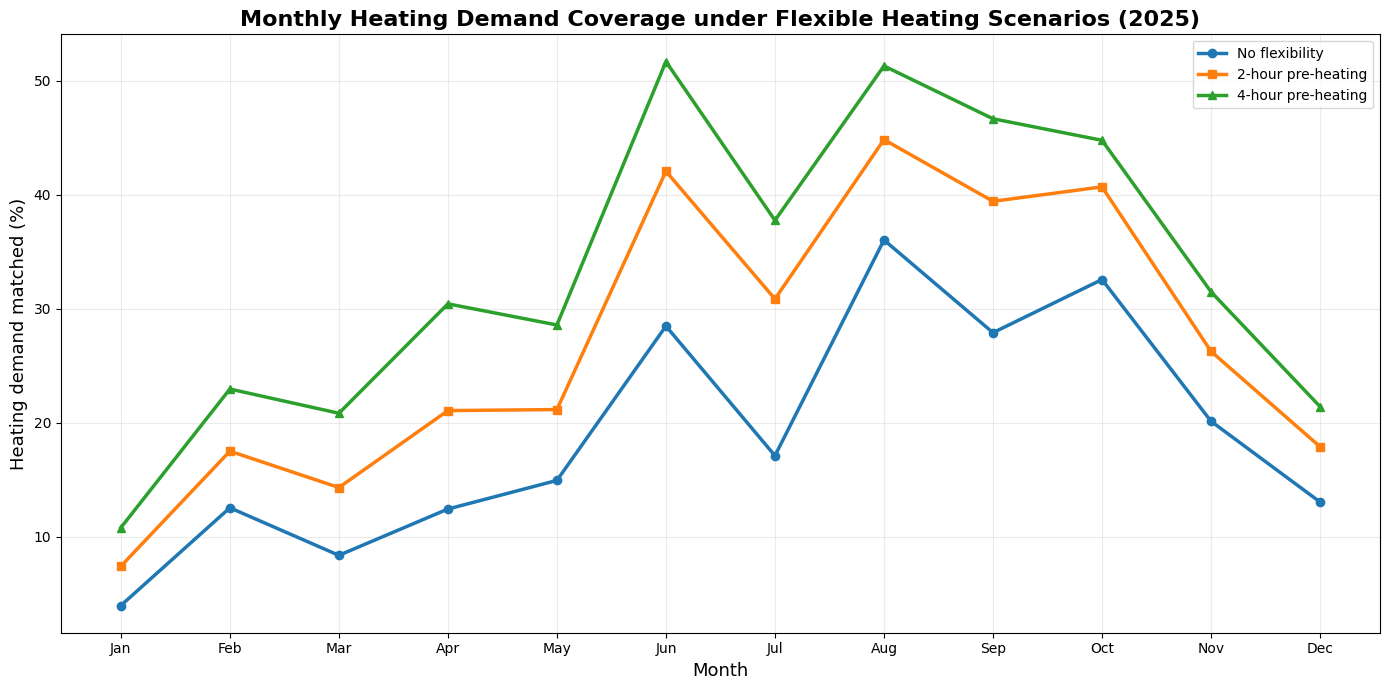

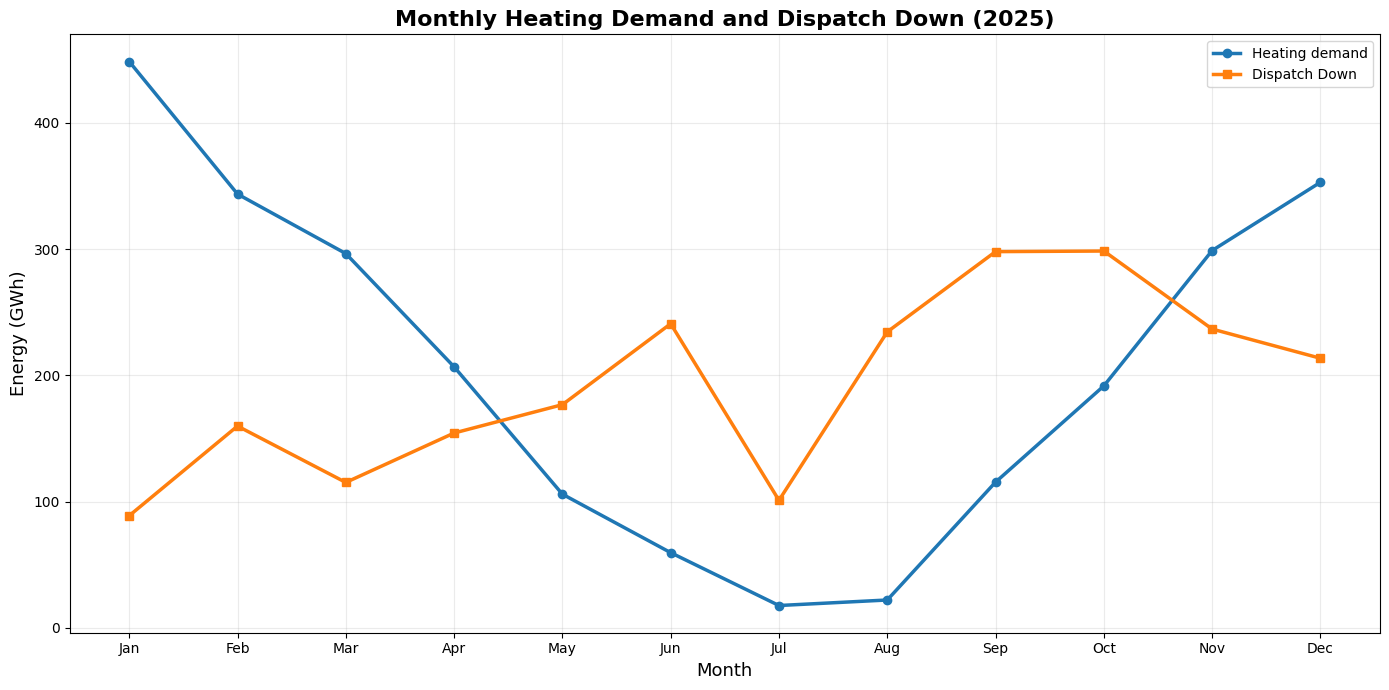



REPRESENTATIVE WINTER WEEK
Start: 2025-01-01 00:00:00
End: 2025-01-07 23:30:00
Number of half-hour intervals: 336


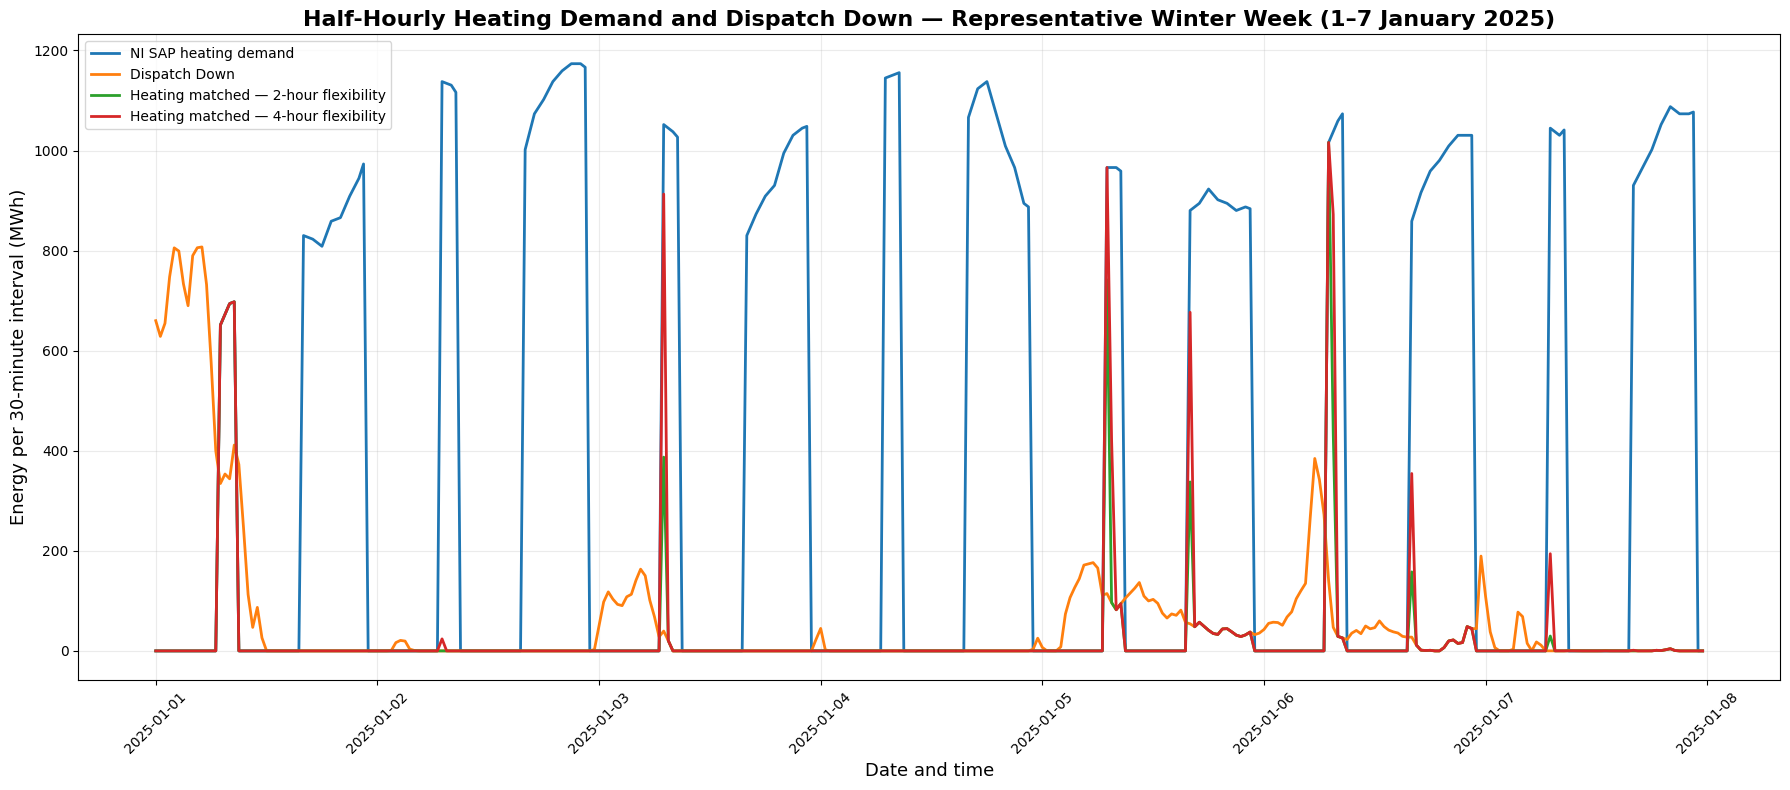

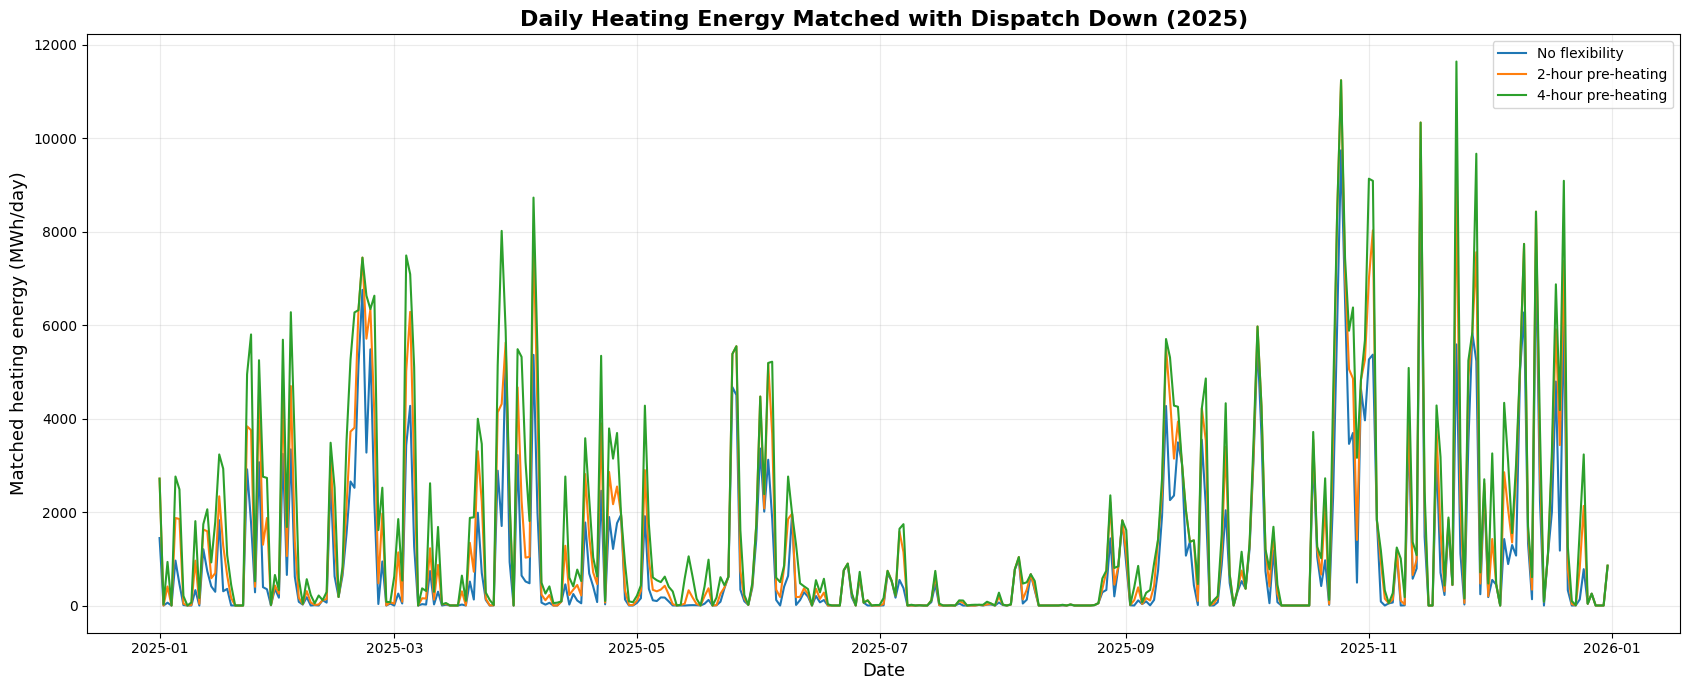



ANALYSIS COMPLETE

Generated files:

1. NI_Flexible_Heating_Analysis_Final_2025.xlsx
2. 01_Annual_Heating_Coverage_Flexibility.png
3. 02_Monthly_Matched_Heating_Energy.png
4. 03_Monthly_Heating_Coverage.png
5. 04_Monthly_Heating_vs_Dispatch_Down.png
6. 05_Winter_Week_Half_Hourly_Matching.png
7. 06_Daily_Heating_Matched.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


IMPORTANT DISSERTATION VALUES

Annual heating demand       : 2459.33 GWh
Annual Dispatch Down        : 2317.72 GWh

No flexibility:
    Matched heating          : 355.45 GWh
    Coverage                 : 14.45 %

2-hour pre-heating:
    Matched heating          : 506.82 GWh
    Coverage                 : 20.61 %
    Additional matched       : 151.37 GWh
    Improvement              : 6.15 percentage points

4-hour pre-heating:
    Matched heating          : 639.87 GWh
    Coverage                 : 26.02 %
    Additional matched       : 284.42 GWh
    Improvement              : 11.56 percentage points

END


In [ ]:
# ==============================================================
# MSc DISSERTATION ANALYSIS
# NI RESIDENTIAL HEATING DEMAND + DISPATCH DOWN
# FLEXIBLE / PRE-HEATING SCENARIOS
#
# Dataset: 2025
# Time resolution: 30 minutes
#
# Scenarios:
#   1. No flexibility
#   2. 2-hour pre-heating flexibility
#   3. 4-hour pre-heating flexibility
#
# IMPORTANT:
# This is a temporal flexibility model.
# It does NOT claim to be a detailed physical thermal-storage
# model of a house.
# ==============================================================


# ==============================================================
# 1. IMPORT LIBRARIES
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("======================================================")
print("NI HEATING FLEXIBILITY ANALYSIS - 2025")
print("======================================================")


# ==============================================================
# 2. UPLOAD EXCEL FILE
# ==============================================================

print("\nUpload your master Excel file:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("\nFile uploaded:")
print(filename)


# ==============================================================
# 3. FIND THE CORRECT SHEET
# ==============================================================

excel_file = pd.ExcelFile(filename)

print("\nSheets found:")
print(excel_file.sheet_names)


selected_sheet = None
header_row = None


# Search first 25 rows of each sheet for the real header
for sheet in excel_file.sheet_names:

    preview = pd.read_excel(
        filename,
        sheet_name=sheet,
        header=None,
        nrows=25
    )

    for r in range(len(preview)):

        row_text = " ".join(
            preview.iloc[r]
            .astype(str)
            .str.lower()
            .tolist()
        )

        if (
            "datetime" in row_text
            and "dispatch" in row_text
            and "heating" in row_text
        ):

            selected_sheet = sheet
            header_row = r
            break

    if selected_sheet is not None:
        break


if selected_sheet is None:

    raise ValueError(
        "Could not automatically find the DateTime/Dispatch/Heating header row."
    )


print("\n======================================================")
print("DATA TABLE FOUND")
print("======================================================")

print("Sheet:", selected_sheet)
print("Header row:", header_row + 1)


# ==============================================================
# 4. READ THE DATA
# ==============================================================

df_raw = pd.read_excel(
    filename,
    sheet_name=selected_sheet,
    header=header_row
)


# ==============================================================
# 5. CLEAN COLUMN NAMES
# ==============================================================

df_raw.columns = (
    df_raw.columns
    .astype(str)
    .str.strip()
    .str.replace("\n", " ", regex=False)
)


print("\nColumns found in Excel:")

for i, col in enumerate(df_raw.columns):
    print(i, ":", col)


# ==============================================================
# 6. FIND THE REQUIRED COLUMNS
# ==============================================================

def find_column(columns, keywords):

    for col in columns:

        text = (
            str(col)
            .lower()
            .replace(" ", "")
            .replace("_", "")
            .replace("-", "")
        )

        if all(
            keyword.lower().replace(" ", "") in text
            for keyword in keywords
        ):
            return col

    return None


datetime_col = find_column(
    df_raw.columns,
    ["datetime"]
)

dispatch_col = find_column(
    df_raw.columns,
    ["dispatch", "down", "mwh"]
)

heating_col = find_column(
    df_raw.columns,
    ["heating", "energy", "ni", "sap"]
)


print("\n======================================================")
print("COLUMN IDENTIFICATION")
print("======================================================")

print("DateTime column:")
print(datetime_col)

print("\nDispatch Down column:")
print(dispatch_col)

print("\nNI SAP Heating column:")
print(heating_col)


# ==============================================================
# 7. CHECK COLUMNS
# ==============================================================

if datetime_col is None:
    raise ValueError("DateTime column could not be found.")

if dispatch_col is None:
    raise ValueError("Dispatch_Down_MWh column could not be found.")

if heating_col is None:
    raise ValueError(
        "NI SAP Heating Energy column could not be found."
    )


# ==============================================================
# 8. EXTRACT AS SERIES
# ==============================================================

date_series = df_raw[datetime_col]

dispatch_series = df_raw[dispatch_col]

heating_series = df_raw[heating_col]


# Handle duplicate Excel column names safely
if isinstance(date_series, pd.DataFrame):
    date_series = date_series.iloc[:, 0]

if isinstance(dispatch_series, pd.DataFrame):
    dispatch_series = dispatch_series.iloc[:, 0]

if isinstance(heating_series, pd.DataFrame):
    heating_series = heating_series.iloc[:, 0]


# ==============================================================
# 9. CREATE CLEAN DATAFRAME
# ==============================================================

df = pd.DataFrame()

df["DateTime"] = pd.to_datetime(
    date_series,
    errors="coerce"
)


# --------------------------------------------------------------
# Dispatch Down:
#
# Excel = MWh
# Model = kWh
#
# 1 MWh = 1000 kWh
# --------------------------------------------------------------

df["Dispatch_Down_kWh"] = (
    pd.to_numeric(
        dispatch_series,
        errors="coerce"
    ).fillna(0)
    * 1000
)


# --------------------------------------------------------------
# Heating:
#
# Excel column is already kWh
# --------------------------------------------------------------

df["Heating_SAP_kWh"] = pd.to_numeric(
    heating_series,
    errors="coerce"
).fillna(0)


# ==============================================================
# 10. REMOVE INVALID RECORDS
# ==============================================================

df = df.dropna(
    subset=["DateTime"]
)


# ==============================================================
# 11. REMOVE NEGATIVE VALUES
# ==============================================================

df["Dispatch_Down_kWh"] = (
    df["Dispatch_Down_kWh"]
    .clip(lower=0)
)

df["Heating_SAP_kWh"] = (
    df["Heating_SAP_kWh"]
    .clip(lower=0)
)


# ==============================================================
# 12. SORT CHRONOLOGICALLY
# ==============================================================

df = df.sort_values(
    "DateTime"
).reset_index(drop=True)


# ==============================================================
# 13. BASIC DATA VALIDATION
# ==============================================================

print("\n======================================================")
print("DATA VALIDATION")
print("======================================================")

print(
    "Number of records:",
    len(df)
)

print(
    "First timestamp:",
    df["DateTime"].min()
)

print(
    "Last timestamp:",
    df["DateTime"].max()
)


# ==============================================================
# 14. CHECK HALF-HOUR RESOLUTION
# ==============================================================

time_intervals = (
    df["DateTime"]
    .diff()
    .dropna()
)


print("\nTime interval distribution:")

print(
    time_intervals
    .value_counts()
    .head(10)
)


# ==============================================================
# 15. ANNUAL ENERGY VALUES
# ==============================================================

annual_dispatch_kWh = (
    df["Dispatch_Down_kWh"].sum()
)

annual_heating_kWh = (
    df["Heating_SAP_kWh"].sum()
)


annual_dispatch_GWh = (
    annual_dispatch_kWh / 1_000_000
)

annual_heating_GWh = (
    annual_heating_kWh / 1_000_000
)


print("\n======================================================")
print("ANNUAL ENERGY")
print("======================================================")

print(
    f"Annual Dispatch Down = "
    f"{annual_dispatch_GWh:.2f} GWh"
)

print(
    f"Annual SAP Heating Demand = "
    f"{annual_heating_GWh:.2f} GWh"
)


# ==============================================================
# 16. NO-FLEXIBILITY MATCHING
# ==============================================================
#
# Dispatch Down can only satisfy heating demand in the
# SAME 30-minute interval.
# ==============================================================

df["Matched_NoFlex_kWh"] = np.minimum(
    df["Heating_SAP_kWh"],
    df["Dispatch_Down_kWh"]
)


df["Unmet_NoFlex_kWh"] = (
    df["Heating_SAP_kWh"]
    - df["Matched_NoFlex_kWh"]
)


# ==============================================================
# 17. FLEXIBLE PRE-HEATING FUNCTION
# ==============================================================
#
# flexibility_hours = 2 or 4
#
# Example:
#
# Heating demand at 06:30
#
# 2-hour flexibility:
#
# 04:30
# 05:00
# 05:30
# 06:00
# 06:30
#
# 4-hour flexibility:
#
# 02:30
# 03:00
# ...
# 06:00
# 06:30
#
# Dispatch Down is consumed once it is used.
# ==============================================================

def calculate_flexible_matching(
    data,
    flexibility_hours
):

    timestep_hours = 0.5

    number_of_steps = int(
        flexibility_hours / timestep_hours
    )

    n = len(data)

    # Available Dispatch Down
    dispatch_remaining = (
        data["Dispatch_Down_kWh"]
        .to_numpy(dtype=float)
        .copy()
    )

    # Heating demand
    heating_demand = (
        data["Heating_SAP_kWh"]
        .to_numpy(dtype=float)
    )

    matched = np.zeros(n)

    unmet = np.zeros(n)

    source_start_index = np.full(
        n,
        -1,
        dtype=int
    )

    source_end_index = np.full(
        n,
        -1,
        dtype=int
    )


    # ----------------------------------------------------------
    # Process heating demand chronologically
    # ----------------------------------------------------------

    for i in range(n):

        demand = heating_demand[i]

        if demand <= 0:
            continue


        # ------------------------------------------------------
        # Start of pre-heating window
        # ------------------------------------------------------

        start_index = max(
            0,
            i - number_of_steps
        )

        end_index = i + 1


        remaining_demand = demand

        first_source = None
        last_source = None


        # ------------------------------------------------------
        # Use oldest available Dispatch Down first
        #
        # This represents using earlier surplus energy
        # to pre-heat the home.
        # ------------------------------------------------------

        for j in range(
            start_index,
            end_index
        ):

            available = (
                dispatch_remaining[j]
            )

            if available <= 0:
                continue


            energy_used = min(
                remaining_demand,
                available
            )


            # Remove used energy
            dispatch_remaining[j] -= (
                energy_used
            )


            # Add matched energy
            matched[i] += energy_used


            # Track source interval
            if first_source is None:
                first_source = j

            last_source = j


            # Remaining demand
            remaining_demand -= (
                energy_used
            )


            if remaining_demand <= 0:
                break


        # ------------------------------------------------------
        # Store results
        # ------------------------------------------------------

        unmet[i] = (
            demand
            - matched[i]
        )


        if first_source is not None:

            source_start_index[i] = (
                first_source
            )

            source_end_index[i] = (
                last_source
            )


    return (
        matched,
        unmet,
        source_start_index,
        source_end_index
    )


# ==============================================================
# 18. RUN 2-HOUR FLEXIBILITY
# ==============================================================

print("\nRunning 2-hour pre-heating scenario...")

(
    matched_2h,
    unmet_2h,
    source_start_2h,
    source_end_2h
) = calculate_flexible_matching(
    df,
    flexibility_hours=2
)


df["Matched_2h_kWh"] = matched_2h

df["Unmet_2h_kWh"] = unmet_2h


# ==============================================================
# 19. RUN 4-HOUR FLEXIBILITY
# ==============================================================

print("Running 4-hour pre-heating scenario...")

(
    matched_4h,
    unmet_4h,
    source_start_4h,
    source_end_4h
) = calculate_flexible_matching(
    df,
    flexibility_hours=4
)


df["Matched_4h_kWh"] = matched_4h

df["Unmet_4h_kWh"] = unmet_4h


# ==============================================================
# 20. ANNUAL RESULTS
# ==============================================================

matched_no_kWh = (
    df["Matched_NoFlex_kWh"].sum()
)

matched_2h_kWh = (
    df["Matched_2h_kWh"].sum()
)

matched_4h_kWh = (
    df["Matched_4h_kWh"].sum()
)


# Convert to GWh

matched_no_GWh = (
    matched_no_kWh / 1_000_000
)

matched_2h_GWh = (
    matched_2h_kWh / 1_000_000
)

matched_4h_GWh = (
    matched_4h_kWh / 1_000_000
)


# ==============================================================
# 21. HEATING DEMAND COVERAGE
# ==============================================================

coverage_no = (
    matched_no_kWh
    / annual_heating_kWh
    * 100
)

coverage_2h = (
    matched_2h_kWh
    / annual_heating_kWh
    * 100
)

coverage_4h = (
    matched_4h_kWh
    / annual_heating_kWh
    * 100
)


# ==============================================================
# 22. ADDITIONAL HEATING MATCHED
# ==============================================================

additional_2h_GWh = (
    matched_2h_GWh
    - matched_no_GWh
)

additional_4h_GWh = (
    matched_4h_GWh
    - matched_no_GWh
)


# Percentage-point improvement

improvement_2h_pp = (
    coverage_2h
    - coverage_no
)

improvement_4h_pp = (
    coverage_4h
    - coverage_no
)


# ==============================================================
# 23. FINAL ANNUAL SUMMARY
# ==============================================================

summary = pd.DataFrame({

    "Scenario": [
        "No flexibility",
        "2-hour pre-heating",
        "4-hour pre-heating"
    ],

    "Total_Heating_Demand_GWh": [
        annual_heating_GWh,
        annual_heating_GWh,
        annual_heating_GWh
    ],

    "Matched_Heating_GWh": [
        matched_no_GWh,
        matched_2h_GWh,
        matched_4h_GWh
    ],

    "Heating_Coverage_percent": [
        coverage_no,
        coverage_2h,
        coverage_4h
    ],

    "Additional_Matched_GWh": [
        0,
        additional_2h_GWh,
        additional_4h_GWh
    ],

    "Improvement_percentage_points": [
        0,
        improvement_2h_pp,
        improvement_4h_pp
    ]
})


print("\n")
print("======================================================")
print("KEY RESULTS FOR DISSERTATION")
print("======================================================")

print(
    f"\nAnnual heating demand:"
    f" {annual_heating_GWh:.2f} GWh"
)

print(
    f"Annual Dispatch Down:"
    f" {annual_dispatch_GWh:.2f} GWh"
)

print(
    f"\nNO FLEXIBILITY"
)

print(
    f"Matched heating:"
    f" {matched_no_GWh:.2f} GWh"
)

print(
    f"Heating coverage:"
    f" {coverage_no:.2f}%"
)


print(
    f"\n2-HOUR PRE-HEATING"
)

print(
    f"Matched heating:"
    f" {matched_2h_GWh:.2f} GWh"
)

print(
    f"Heating coverage:"
    f" {coverage_2h:.2f}%"
)

print(
    f"Additional matched:"
    f" {additional_2h_GWh:.2f} GWh"
)

print(
    f"Improvement:"
    f" {improvement_2h_pp:.2f} percentage points"
)


print(
    f"\n4-HOUR PRE-HEATING"
)

print(
    f"Matched heating:"
    f" {matched_4h_GWh:.2f} GWh"
)

print(
    f"Heating coverage:"
    f" {coverage_4h:.2f}%"
)

print(
    f"Additional matched:"
    f" {additional_4h_GWh:.2f} GWh"
)

print(
    f"Improvement:"
    f" {improvement_4h_pp:.2f} percentage points"
)


# ==============================================================
# 24. MONTH INFORMATION
# ==============================================================

df["Month_Number"] = (
    df["DateTime"].dt.month
)

df["Month"] = (
    df["DateTime"].dt.strftime("%b")
)


month_order = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]


# ==============================================================
# 25. MONTHLY ANALYSIS
# ==============================================================

monthly = df.groupby(
    ["Month_Number", "Month"]
).agg({

    "Heating_SAP_kWh": "sum",

    "Dispatch_Down_kWh": "sum",

    "Matched_NoFlex_kWh": "sum",

    "Matched_2h_kWh": "sum",

    "Matched_4h_kWh": "sum"

}).reset_index()


monthly = monthly.sort_values(
    "Month_Number"
)


# Convert to GWh

monthly["Heating_Demand_GWh"] = (
    monthly["Heating_SAP_kWh"]
    / 1_000_000
)

monthly["Dispatch_Down_GWh"] = (
    monthly["Dispatch_Down_kWh"]
    / 1_000_000
)

monthly["No_Flexibility_GWh"] = (
    monthly["Matched_NoFlex_kWh"]
    / 1_000_000
)

monthly["2h_Flexibility_GWh"] = (
    monthly["Matched_2h_kWh"]
    / 1_000_000
)

monthly["4h_Flexibility_GWh"] = (
    monthly["Matched_4h_kWh"]
    / 1_000_000
)


# Monthly coverage

monthly["No_Flex_Coverage_%"] = (
    monthly["No_Flexibility_GWh"]
    / monthly["Heating_Demand_GWh"]
    * 100
)

monthly["2h_Coverage_%"] = (
    monthly["2h_Flexibility_GWh"]
    / monthly["Heating_Demand_GWh"]
    * 100
)

monthly["4h_Coverage_%"] = (
    monthly["4h_Flexibility_GWh"]
    / monthly["Heating_Demand_GWh"]
    * 100
)


# ==============================================================
# 26. DISPLAY MONTHLY RESULTS
# ==============================================================

print("\n")
print("======================================================")
print("MONTHLY RESULTS")
print("======================================================")

print(
    monthly[
        [
            "Month",
            "Heating_Demand_GWh",
            "Dispatch_Down_GWh",
            "No_Flexibility_GWh",
            "2h_Flexibility_GWh",
            "4h_Flexibility_GWh",
            "2h_Coverage_%",
            "4h_Coverage_%"
        ]
    ].round(2).to_string(index=False)
)


# ==============================================================
# 27. FIGURE 1
# ANNUAL HEATING COVERAGE
# ==============================================================

plt.figure(
    figsize=(11, 7)
)

scenarios = [
    "No flexibility",
    "2-hour\npre-heating",
    "4-hour\npre-heating"
]

coverage_values = [
    coverage_no,
    coverage_2h,
    coverage_4h
]

bars = plt.bar(
    scenarios,
    coverage_values
)


plt.ylabel(
    "Heating demand matched (%)",
    fontsize=13
)

plt.xlabel(
    "Flexibility scenario",
    fontsize=13
)

plt.title(
    "Potential Increase in Heating Demand Coverage "
    "through Temporal Flexibility (2025)",
    fontsize=16,
    fontweight="bold"
)


for bar, value in zip(
    bars,
    coverage_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 0.5,

        f"{value:.2f}%",

        ha="center",
        va="bottom",

        fontsize=12,
        fontweight="bold"
    )


plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()


figure1 = (
    "01_Annual_Heating_Coverage_Flexibility.png"
)

plt.savefig(
    figure1,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ==============================================================
# 28. FIGURE 2
# MONTHLY MATCHED HEATING ENERGY
# ==============================================================

plt.figure(
    figsize=(14, 7)
)

x = np.arange(12)

plt.plot(
    x,
    monthly["No_Flexibility_GWh"],
    marker="o",
    linewidth=2.5,
    label="No flexibility"
)

plt.plot(
    x,
    monthly["2h_Flexibility_GWh"],
    marker="s",
    linewidth=2.5,
    label="2-hour pre-heating"
)

plt.plot(
    x,
    monthly["4h_Flexibility_GWh"],
    marker="^",
    linewidth=2.5,
    label="4-hour pre-heating"
)


plt.xticks(
    x,
    month_order
)

plt.ylabel(
    "Matched heating energy (GWh)",
    fontsize=13
)

plt.xlabel(
    "Month",
    fontsize=13
)

plt.title(
    "Monthly Heating Energy Matched under Different "
    "Flexibility Scenarios (2025)",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


figure2 = (
    "02_Monthly_Matched_Heating_Energy.png"
)

plt.savefig(
    figure2,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ==============================================================
# 29. FIGURE 3
# MONTHLY HEATING COVERAGE
# ==============================================================

plt.figure(
    figsize=(14, 7)
)

plt.plot(
    x,
    monthly["No_Flex_Coverage_%"],
    marker="o",
    linewidth=2.5,
    label="No flexibility"
)

plt.plot(
    x,
    monthly["2h_Coverage_%"],
    marker="s",
    linewidth=2.5,
    label="2-hour pre-heating"
)

plt.plot(
    x,
    monthly["4h_Coverage_%"],
    marker="^",
    linewidth=2.5,
    label="4-hour pre-heating"
)


plt.xticks(
    x,
    month_order
)

plt.ylabel(
    "Heating demand matched (%)",
    fontsize=13
)

plt.xlabel(
    "Month",
    fontsize=13
)

plt.title(
    "Monthly Heating Demand Coverage "
    "under Flexible Heating Scenarios (2025)",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


figure3 = (
    "03_Monthly_Heating_Coverage.png"
)

plt.savefig(
    figure3,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ==============================================================
# 30. FIGURE 4
# MONTHLY HEATING DEMAND VS DISPATCH DOWN
# ==============================================================

plt.figure(
    figsize=(14, 7)
)

plt.plot(
    x,
    monthly["Heating_Demand_GWh"],
    marker="o",
    linewidth=2.5,
    label="Heating demand"
)

plt.plot(
    x,
    monthly["Dispatch_Down_GWh"],
    marker="s",
    linewidth=2.5,
    label="Dispatch Down"
)


plt.xticks(
    x,
    month_order
)

plt.ylabel(
    "Energy (GWh)",
    fontsize=13
)

plt.xlabel(
    "Month",
    fontsize=13
)

plt.title(
    "Monthly Heating Demand and Dispatch Down (2025)",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


figure4 = (
    "04_Monthly_Heating_vs_Dispatch_Down.png"
)

plt.savefig(
    figure4,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ==============================================================
# 31. REPRESENTATIVE WINTER WEEK
# ==============================================================
#
# Actual dates:
#
# 01 January 2025 00:00
# through
# 07 January 2025 23:30
#
# This preserves the 30-minute resolution.
# ==============================================================

winter_start = pd.Timestamp(
    "2025-01-01 00:00"
)

winter_end = pd.Timestamp(
    "2025-01-08 00:00"
)


winter_week = df[
    (
        df["DateTime"] >= winter_start
    )
    &
    (
        df["DateTime"] < winter_end
    )
].copy()


print("\n")
print("======================================================")
print("REPRESENTATIVE WINTER WEEK")
print("======================================================")

print(
    "Start:",
    winter_week["DateTime"].min()
)

print(
    "End:",
    winter_week["DateTime"].max()
)

print(
    "Number of half-hour intervals:",
    len(winter_week)
)


# ==============================================================
# 32. FIGURE 5
# HALF-HOURLY WINTER WEEK
# ==============================================================

plt.figure(
    figsize=(18, 8)
)


plt.plot(
    winter_week["DateTime"],
    winter_week["Heating_SAP_kWh"] / 1000,
    linewidth=2,
    label="NI SAP heating demand"
)


plt.plot(
    winter_week["DateTime"],
    winter_week["Dispatch_Down_kWh"] / 1000,
    linewidth=2,
    label="Dispatch Down"
)


plt.plot(
    winter_week["DateTime"],
    winter_week["Matched_2h_kWh"] / 1000,
    linewidth=2,
    label="Heating matched — 2-hour flexibility"
)


plt.plot(
    winter_week["DateTime"],
    winter_week["Matched_4h_kWh"] / 1000,
    linewidth=2,
    label="Heating matched — 4-hour flexibility"
)


plt.ylabel(
    "Energy per 30-minute interval (MWh)",
    fontsize=13
)

plt.xlabel(
    "Date and time",
    fontsize=13
)

plt.title(
    "Half-Hourly Heating Demand and Dispatch Down — "
    "Representative Winter Week (1–7 January 2025)",
    fontsize=16,
    fontweight="bold"
)


plt.legend()

plt.grid(
    alpha=0.25
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


figure5 = (
    "05_Winter_Week_Half_Hourly_Matching.png"
)

plt.savefig(
    figure5,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ==============================================================
# 33. FIGURE 6
# DAILY MATCHED HEATING
# ==============================================================

df["Date"] = (
    df["DateTime"].dt.date
)


daily = df.groupby(
    "Date"
).agg({

    "Heating_SAP_kWh": "sum",

    "Dispatch_Down_kWh": "sum",

    "Matched_NoFlex_kWh": "sum",

    "Matched_2h_kWh": "sum",

    "Matched_4h_kWh": "sum"

})


plt.figure(
    figsize=(17, 7)
)


plt.plot(
    pd.to_datetime(daily.index),
    daily["Matched_NoFlex_kWh"] / 1000,
    linewidth=1.5,
    label="No flexibility"
)


plt.plot(
    pd.to_datetime(daily.index),
    daily["Matched_2h_kWh"] / 1000,
    linewidth=1.5,
    label="2-hour pre-heating"
)


plt.plot(
    pd.to_datetime(daily.index),
    daily["Matched_4h_kWh"] / 1000,
    linewidth=1.5,
    label="4-hour pre-heating"
)


plt.ylabel(
    "Matched heating energy (MWh/day)",
    fontsize=13
)

plt.xlabel(
    "Date",
    fontsize=13
)

plt.title(
    "Daily Heating Energy Matched with Dispatch Down (2025)",
    fontsize=16,
    fontweight="bold"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


figure6 = (
    "06_Daily_Heating_Matched.png"
)

plt.savefig(
    figure6,
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ==============================================================
# 34. CREATE DETAILED MONTHLY TABLE
# ==============================================================

monthly_output = monthly[
    [
        "Month",
        "Heating_Demand_GWh",
        "Dispatch_Down_GWh",
        "No_Flexibility_GWh",
        "2h_Flexibility_GWh",
        "4h_Flexibility_GWh",
        "No_Flex_Coverage_%",
        "2h_Coverage_%",
        "4h_Coverage_%"
    ]
].copy()


# ==============================================================
# 35. CREATE ANNUAL SUMMARY TABLE
# ==============================================================

annual_summary = summary.copy()


# ==============================================================
# 36. EXPORT FULL RESULTS TO EXCEL
# ==============================================================

output_excel = (
    "NI_Flexible_Heating_Analysis_Final_2025.xlsx"
)


with pd.ExcelWriter(
    output_excel,
    engine="openpyxl"
) as writer:

    # Full half-hourly calculation
    df.to_excel(
        writer,
        sheet_name="Half_Hourly_Results",
        index=False
    )

    # Annual results
    annual_summary.to_excel(
        writer,
        sheet_name="Annual_Summary",
        index=False
    )

    # Monthly results
    monthly_output.to_excel(
        writer,
        sheet_name="Monthly_Results",
        index=False
    )

    # Daily results
    daily.to_excel(
        writer,
        sheet_name="Daily_Results"
    )


# ==============================================================
# 37. FINAL FILE LIST
# ==============================================================

print("\n")
print("======================================================")
print("ANALYSIS COMPLETE")
print("======================================================")

print("\nGenerated files:")

print(
    "\n1.",
    output_excel
)

print(
    "2.",
    figure1
)

print(
    "3.",
    figure2
)

print(
    "4.",
    figure3
)

print(
    "5.",
    figure4
)

print(
    "6.",
    figure5
)

print(
    "7.",
    figure6
)


# ==============================================================
# 38. DOWNLOAD FILES
# ==============================================================

files.download(
    output_excel
)

files.download(
    figure1
)

files.download(
    figure2
)

files.download(
    figure3
)

files.download(
    figure4
)

files.download(
    figure5
)

files.download(
    figure6
)


print("\n======================================================")
print("IMPORTANT DISSERTATION VALUES")
print("======================================================")

print(
    f"""
Annual heating demand       : {annual_heating_GWh:.2f} GWh
Annual Dispatch Down        : {annual_dispatch_GWh:.2f} GWh

No flexibility:
    Matched heating          : {matched_no_GWh:.2f} GWh
    Coverage                 : {coverage_no:.2f} %

2-hour pre-heating:
    Matched heating          : {matched_2h_GWh:.2f} GWh
    Coverage                 : {coverage_2h:.2f} %
    Additional matched       : {additional_2h_GWh:.2f} GWh
    Improvement              : {improvement_2h_pp:.2f} percentage points

4-hour pre-heating:
    Matched heating          : {matched_4h_GWh:.2f} GWh
    Coverage                 : {coverage_4h:.2f} %
    Additional matched       : {additional_4h_GWh:.2f} GWh
    Improvement              : {improvement_4h_pp:.2f} percentage points
"""
)

print("======================================================")
print("END")
print("======================================================")

Upload:
1. Excel Sheet.xlsx
2. Weather_2025_halfhourly.xlsx


Saving Weather_2025_halfhourly.xlsx to Weather_2025_halfhourly.xlsx
Saving Excel Sheet.xlsx to Excel Sheet.xlsx

================ DATA CHECK ================
Dispatch Down rows: 17518 | unique timestamps: 17518
System rows: 35040 | unique timestamps: 35036
Weather rows: 26303 | unique timestamps: 26303

Merged rows: 17520
Start: 2025-01-01 00:00:00
End: 2025-12-31 23:30:00


IMPORTANT DISSERTATION VALUES

Annual heating demand : 0.00 GWh
Annual Dispatch Down  : 2,317.72 GWh

NO FLEXIBILITY
Matched heating : 0.00 GWh
Heating coverage: 62.44%

2-HOUR PRE-HEATING
Matched heating : 0.00 GWh
Heating coverage: 68.08%
Additional matched: 0.00 GWh
Improvement: 5.64 percentage points

4-HOUR PRE-HEATING
Matched heating : 0.00 GWh
Heating coverage: 73.88%
Additional matched: 0.00 GWh
Improvement: 11.44 percentage points


MONTHLY RESULTS
            Heating_Demand_GWh  Dispatch_Down_GWh  No_Flexibility_GWh  \
DateTime                                                                
2025-01-31    

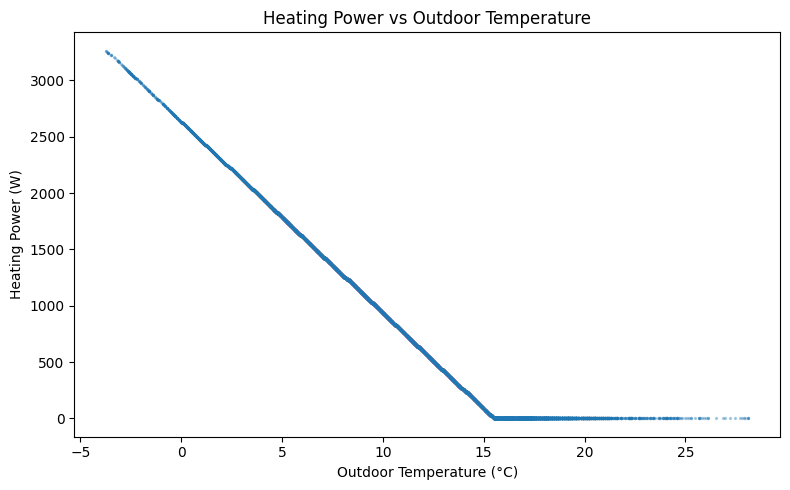

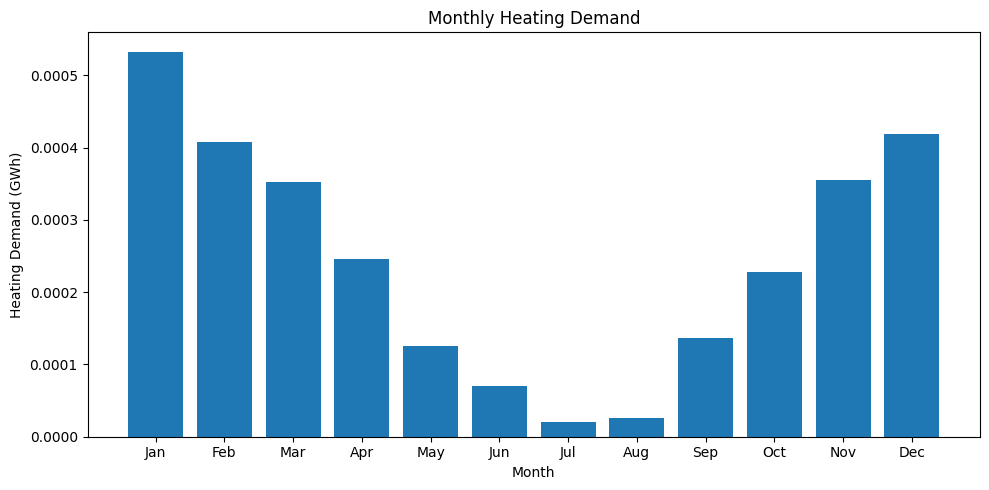

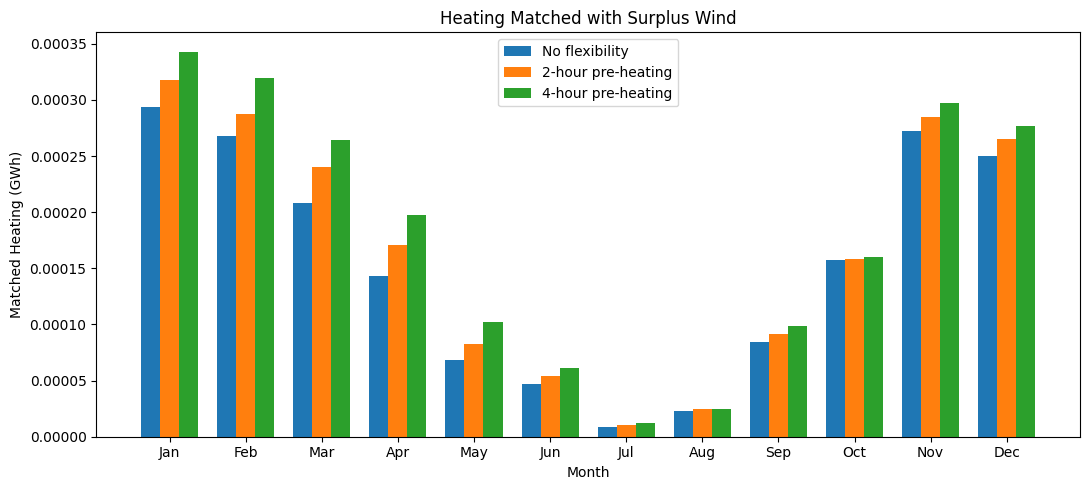

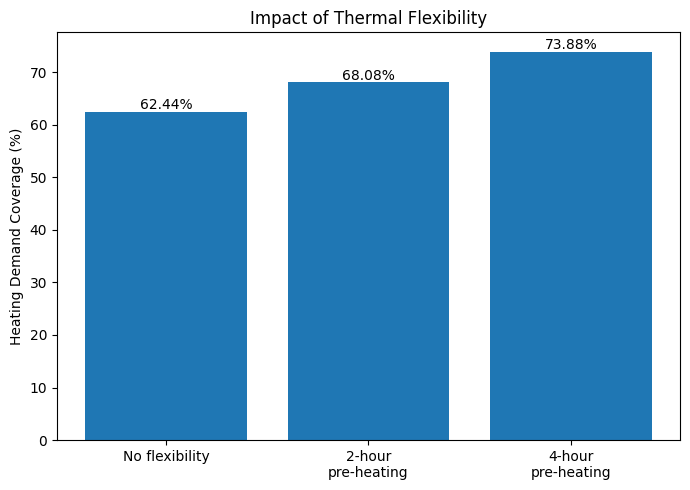

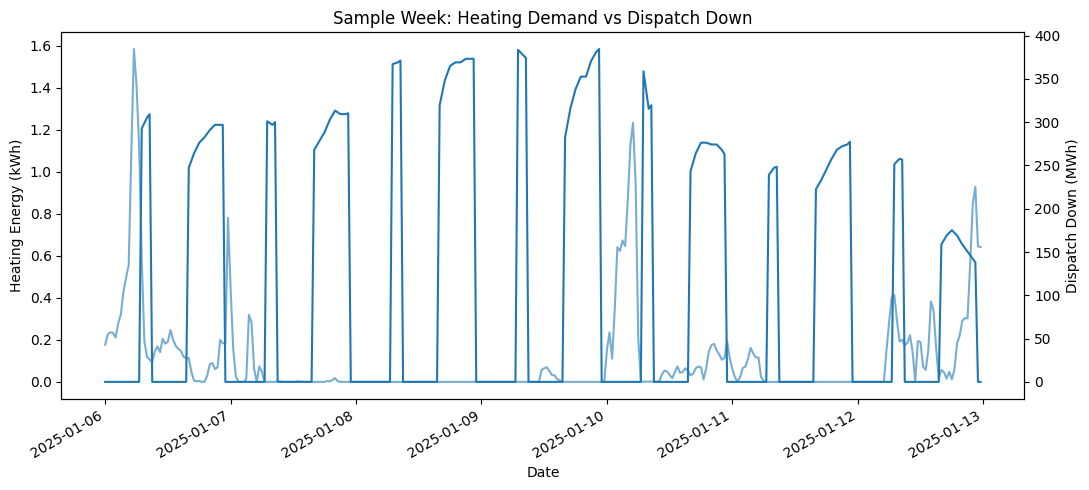

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



ANALYSIS COMPLETE


In [ ]:
# ============================================================
# MSc DISSERTATION
# Heating Demand + Wind Curtailment + Thermal Flexibility
# Northern Ireland - 2025
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. UPLOAD FILES
# ============================================================

print("Upload:")
print("1. Excel Sheet.xlsx")
print("2. Weather_2025_halfhourly.xlsx")

uploaded = files.upload()


# ============================================================
# 2. READ DISPATCH-DOWN DATA
# ============================================================

dd = pd.read_excel(
    "Excel Sheet.xlsx",
    sheet_name="DD_2025"
)

dd = dd[["HH_TIMESTAMP", "Sum of DD_MWH"]]

dd.columns = [
    "DateTime",
    "Dispatch_Down_MWh"
]

dd["DateTime"] = pd.to_datetime(dd["DateTime"])

# Combine duplicate timestamps if present
dd = (
    dd.groupby("DateTime", as_index=False)
      ["Dispatch_Down_MWh"]
      .sum()
)


# ============================================================
# 3. READ NI SYSTEM DATA
# ============================================================

system = pd.read_excel(
    "Excel Sheet.xlsx",
    sheet_name="System_2025"
)

system = system[
    [
        "DateTime",
        "NI Demand",
        "NI Wind Generation"
    ]
]

system["DateTime"] = pd.to_datetime(system["DateTime"])


# ============================================================
# 4. READ WEATHER DATA
# ============================================================

weather = pd.read_excel(
    "Weather_2025_halfhourly.xlsx"
)

# Find columns automatically
datetime_col = [
    c for c in weather.columns
    if "DateTime" in c
][0]

temp_col = [
    c for c in weather.columns
    if "temperature" in c.lower()
][0]

wind_col = [
    c for c in weather.columns
    if "wind_speed" in c.lower()
][0]

humidity_col = [
    c for c in weather.columns
    if "humidity" in c.lower()
][0]

weather = weather[
    [
        datetime_col,
        temp_col,
        wind_col,
        humidity_col
    ]
]

weather.columns = [
    "DateTime",
    "Temperature",
    "Wind_Speed",
    "Relative_Humidity"
]

weather["DateTime"] = pd.to_datetime(
    weather["DateTime"]
)


# ============================================================
# 5. CHECK DATA
# ============================================================

print("\n================ DATA CHECK ================")

print(
    "Dispatch Down rows:",
    len(dd),
    "| unique timestamps:",
    dd["DateTime"].nunique()
)

print(
    "System rows:",
    len(system),
    "| unique timestamps:",
    system["DateTime"].nunique()
)

print(
    "Weather rows:",
    len(weather),
    "| unique timestamps:",
    weather["DateTime"].nunique()
)


# ============================================================
# 6. MERGE DATA
# ============================================================

merged = dd.merge(
    system,
    on="DateTime",
    how="inner"
)

merged = merged.merge(
    weather,
    on="DateTime",
    how="inner"
)

# Sort chronologically
merged = (
    merged
    .sort_values("DateTime")
    .reset_index(drop=True)
)


# ============================================================
# 7. KEEP ONLY 2025
# ============================================================

merged = merged[
    (merged["DateTime"] >= "2025-01-01") &
    (merged["DateTime"] < "2026-01-01")
].copy()

merged = (
    merged
    .sort_values("DateTime")
    .reset_index(drop=True)
)


print("\nMerged rows:", len(merged))
print(
    "Start:",
    merged["DateTime"].min()
)

print(
    "End:",
    merged["DateTime"].max()
)


# ============================================================
# 8. HEATING DEMAND MODEL
# ============================================================

# Heat Transfer Coefficient from SAP assessment
HTC = 170       # W/K

# Base / balance temperature
BASE_TEMP = 15.5    # °C


# Temperature difference below base temperature
merged["Degree_Difference"] = (
    BASE_TEMP - merged["Temperature"]
).clip(lower=0)


# Heating power
merged["Heating_Power_W"] = (
    HTC * merged["Degree_Difference"]
)


# Half-hour heating energy
merged["Heating_Energy_24h_kWh"] = (
    merged["Heating_Power_W"] * 0.5 / 1000
)


# ============================================================
# 9. SAP HEATING WINDOW
# ============================================================

hour = (
    merged["DateTime"].dt.hour
    + merged["DateTime"].dt.minute / 60
)

# 07:00-09:00
# 16:00-23:00

sap_mask = (
    ((hour >= 7) & (hour < 9))
    |
    ((hour >= 16) & (hour < 23))
)

merged["Heating_Energy_SAP_kWh"] = (
    merged["Heating_Energy_24h_kWh"]
    .where(sap_mask, 0)
)


# ============================================================
# 10. REALISTIC WARM-UP WINDOW
# ============================================================

# 06:30-08:30
# 15:30-22:30

realistic_mask = (
    ((hour >= 6.5) & (hour < 8.5))
    |
    ((hour >= 15.5) & (hour < 22.5))
)

merged["Heating_Energy_Realistic_kWh"] = (
    merged["Heating_Energy_24h_kWh"]
    .where(realistic_mask, 0)
)


# ============================================================
# 11. SURPLUS / CURTAILMENT
# ============================================================

merged["Surplus_Wind"] = (
    merged["Dispatch_Down_MWh"] > 0
)


# Convert curtailed wind from MWh to kWh
merged["Dispatch_Down_kWh"] = (
    merged["Dispatch_Down_MWh"] * 1000
)


# ============================================================
# 12. NO-FLEXIBILITY CASE
# ============================================================

# Heating can only be supplied by curtailed wind
# in the same half-hour.

merged["Matched_No_Flex_kWh"] = np.minimum(
    merged["Heating_Energy_SAP_kWh"],
    merged["Dispatch_Down_kWh"]
)

annual_heating = (
    merged["Heating_Energy_SAP_kWh"].sum()
)

annual_dispatch = (
    merged["Dispatch_Down_kWh"].sum()
)

matched_no_flex = (
    merged["Matched_No_Flex_kWh"].sum()
)

coverage_no_flex = (
    100 * matched_no_flex / annual_heating
)


# ============================================================
# 13. 2-HOUR PRE-HEATING
# ============================================================

# Available curtailed wind can be used to satisfy
# heating demand occurring within the following 2 hours.

merged["Matched_2h_kWh"] = 0.0

heating = (
    merged["Heating_Energy_SAP_kWh"]
    .values
)

surplus = (
    merged["Dispatch_Down_kWh"]
    .values
)

n = len(merged)

for i in range(n):

    if surplus[i] <= 0:
        continue

    # Current half-hour + next 3 half-hours
    end = min(i + 4, n)

    available_wind = surplus[i]

    for j in range(i, end):

        remaining_heat = (
            heating[j]
            - merged.loc[j, "Matched_2h_kWh"]
        )

        if remaining_heat <= 0:
            continue

        allocation = min(
            available_wind,
            remaining_heat
        )

        merged.loc[
            j,
            "Matched_2h_kWh"
        ] += allocation

        available_wind -= allocation

        if available_wind <= 0:
            break


matched_2h = (
    merged["Matched_2h_kWh"].sum()
)

coverage_2h = (
    100 * matched_2h / annual_heating
)

additional_2h = (
    matched_2h - matched_no_flex
)

improvement_2h = (
    coverage_2h - coverage_no_flex
)


# ============================================================
# 14. 4-HOUR PRE-HEATING
# ============================================================

merged["Matched_4h_kWh"] = 0.0

for i in range(n):

    if surplus[i] <= 0:
        continue

    # Current half-hour + next 7 half-hours
    end = min(i + 8, n)

    available_wind = surplus[i]

    for j in range(i, end):

        remaining_heat = (
            heating[j]
            - merged.loc[j, "Matched_4h_kWh"]
        )

        if remaining_heat <= 0:
            continue

        allocation = min(
            available_wind,
            remaining_heat
        )

        merged.loc[
            j,
            "Matched_4h_kWh"
        ] += allocation

        available_wind -= allocation

        if available_wind <= 0:
            break


matched_4h = (
    merged["Matched_4h_kWh"].sum()
)

coverage_4h = (
    100 * matched_4h / annual_heating
)

additional_4h = (
    matched_4h - matched_no_flex
)

improvement_4h = (
    coverage_4h - coverage_no_flex
)


# ============================================================
# 15. ANNUAL RESULTS
# ============================================================

print("\n")
print("=" * 65)
print("IMPORTANT DISSERTATION VALUES")
print("=" * 65)

print(
    f"\nAnnual heating demand : "
    f"{annual_heating/1e6:,.2f} GWh"
)

print(
    f"Annual Dispatch Down  : "
    f"{annual_dispatch/1e6:,.2f} GWh"
)


print("\nNO FLEXIBILITY")

print(
    f"Matched heating : "
    f"{matched_no_flex/1e6:,.2f} GWh"
)

print(
    f"Heating coverage: "
    f"{coverage_no_flex:.2f}%"
)


print("\n2-HOUR PRE-HEATING")

print(
    f"Matched heating : "
    f"{matched_2h/1e6:,.2f} GWh"
)

print(
    f"Heating coverage: "
    f"{coverage_2h:.2f}%"
)

print(
    f"Additional matched: "
    f"{additional_2h/1e6:,.2f} GWh"
)

print(
    f"Improvement: "
    f"{improvement_2h:.2f} percentage points"
)


print("\n4-HOUR PRE-HEATING")

print(
    f"Matched heating : "
    f"{matched_4h/1e6:,.2f} GWh"
)

print(
    f"Heating coverage: "
    f"{coverage_4h:.2f}%"
)

print(
    f"Additional matched: "
    f"{additional_4h/1e6:,.2f} GWh"
)

print(
    f"Improvement: "
    f"{improvement_4h:.2f} percentage points"
)


# ============================================================
# 16. MONTHLY RESULTS
# ============================================================

merged["Month"] = (
    merged["DateTime"]
    .dt.strftime("%b")
)

monthly = (
    merged
    .set_index("DateTime")
    [
        [
            "Heating_Energy_SAP_kWh",
            "Dispatch_Down_kWh",
            "Matched_No_Flex_kWh",
            "Matched_2h_kWh",
            "Matched_4h_kWh"
        ]
    ]
    .resample("ME")
    .sum()
)

monthly["Heating_Demand_GWh"] = (
    monthly["Heating_Energy_SAP_kWh"] / 1e6
)

monthly["Dispatch_Down_GWh"] = (
    monthly["Dispatch_Down_kWh"] / 1e6
)

monthly["No_Flexibility_GWh"] = (
    monthly["Matched_No_Flex_kWh"] / 1e6
)

monthly["2h_Flexibility_GWh"] = (
    monthly["Matched_2h_kWh"] / 1e6
)

monthly["4h_Flexibility_GWh"] = (
    monthly["Matched_4h_kWh"] / 1e6
)

monthly["2h_Coverage_%"] = (
    100
    * monthly["2h_Flexibility_GWh"]
    / monthly["Heating_Demand_GWh"]
)

monthly["4h_Coverage_%"] = (
    100
    * monthly["4h_Flexibility_GWh"]
    / monthly["Heating_Demand_GWh"]
)


print("\n")
print("=" * 100)
print("MONTHLY RESULTS")
print("=" * 100)

print(
    monthly[
        [
            "Heating_Demand_GWh",
            "Dispatch_Down_GWh",
            "No_Flexibility_GWh",
            "2h_Flexibility_GWh",
            "4h_Flexibility_GWh",
            "2h_Coverage_%",
            "4h_Coverage_%"
        ]
    ].round(2)
)


# ============================================================
# 17. SURPLUS-WIND OVERLAP
# ============================================================

surplus_heating = (
    merged.loc[
        merged["Surplus_Wind"],
        "Heating_Energy_SAP_kWh"
    ].sum()
)

total_heating = (
    merged["Heating_Energy_SAP_kWh"].sum()
)

non_surplus_heating = (
    total_heating - surplus_heating
)

surplus_percentage = (
    100 * surplus_heating / total_heating
)


print("\n")
print("=" * 65)
print("HEATING DEMAND DURING SURPLUS WIND")
print("=" * 65)

print(
    f"Heating demand during surplus wind: "
    f"{surplus_heating/1e6:,.2f} GWh"
)

print(
    f"Heating demand outside surplus wind: "
    f"{non_surplus_heating/1e6:,.2f} GWh"
)

print(
    f"Percentage of heating demand occurring "
    f"during surplus wind: "
    f"{surplus_percentage:.2f}%"
)


# ============================================================
# 18. SAVE COMPLETE DATASET
# ============================================================

output_file = (
    "Merged_2025_Heating_Wind_Flexibility.xlsx"
)

merged.to_excel(
    output_file,
    index=False
)

print("\nSaved:", output_file)


# ============================================================
# 19. PLOT 1
# HEATING POWER VS TEMPERATURE
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    merged["Temperature"],
    merged["Heating_Power_W"],
    s=2,
    alpha=0.3
)

plt.xlabel("Outdoor Temperature (°C)")
plt.ylabel("Heating Power (W)")
plt.title("Heating Power vs Outdoor Temperature")

plt.tight_layout()
plt.show()


# ============================================================
# 20. PLOT 2
# MONTHLY HEATING DEMAND
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    monthly.index.strftime("%b"),
    monthly["Heating_Demand_GWh"]
)

plt.xlabel("Month")
plt.ylabel("Heating Demand (GWh)")
plt.title("Monthly Heating Demand")

plt.tight_layout()
plt.show()


# ============================================================
# 21. PLOT 3
# MONTHLY FLEXIBILITY COMPARISON
# ============================================================

x = np.arange(len(monthly))
width = 0.25

plt.figure(figsize=(11, 5))

plt.bar(
    x - width,
    monthly["No_Flexibility_GWh"],
    width,
    label="No flexibility"
)

plt.bar(
    x,
    monthly["2h_Flexibility_GWh"],
    width,
    label="2-hour pre-heating"
)

plt.bar(
    x + width,
    monthly["4h_Flexibility_GWh"],
    width,
    label="4-hour pre-heating"
)

plt.xticks(
    x,
    monthly.index.strftime("%b")
)

plt.xlabel("Month")
plt.ylabel("Matched Heating (GWh)")
plt.title("Heating Matched with Surplus Wind")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 22. PLOT 4
# COVERAGE COMPARISON
# ============================================================

plt.figure(figsize=(7, 5))

coverage_values = [
    coverage_no_flex,
    coverage_2h,
    coverage_4h
]

labels = [
    "No flexibility",
    "2-hour\npre-heating",
    "4-hour\npre-heating"
]

plt.bar(
    labels,
    coverage_values
)

plt.ylabel("Heating Demand Coverage (%)")
plt.title("Impact of Thermal Flexibility")

for i, value in enumerate(coverage_values):

    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 23. PLOT 5
# SAMPLE WEEK
# ============================================================

sample = merged[
    (merged["DateTime"] >= "2025-01-06") &
    (merged["DateTime"] < "2025-01-13")
]

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    sample["DateTime"],
    sample["Heating_Energy_SAP_kWh"],
    label="Heating demand"
)

ax1.set_xlabel("Date")
ax1.set_ylabel(
    "Heating Energy (kWh)"
)

ax2 = ax1.twinx()

ax2.plot(
    sample["DateTime"],
    sample["Dispatch_Down_MWh"],
    alpha=0.6,
    label="Dispatch Down"
)

ax2.set_ylabel(
    "Dispatch Down (MWh)"
)

ax1.set_title(
    "Sample Week: Heating Demand vs Dispatch Down"
)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


# ============================================================
# 24. DOWNLOAD
# ============================================================

files.download(output_file)

print("\n")
print("=" * 65)
print("ANALYSIS COMPLETE")
print("=" * 65)

In [ ]:
# ============================================================
# MSc DISSERTATION
# FINAL SYSTEM-LEVEL THERMAL FLEXIBILITY CALCULATION
# Northern Ireland - 2025
# ============================================================

import pandas as pd
import numpy as np
from google.colab import files

# ============================================================
# 1. UPLOAD / READ YOUR MERGED FILE
# ============================================================

print("Upload: Merged_2025_Heating_Wind_Flexibility.xlsx")

uploaded = files.upload()

input_file = "Merged_2025_Heating_Wind_Flexibility.xlsx"

df = pd.read_excel(input_file)

df["DateTime"] = pd.to_datetime(df["DateTime"])

df = (
    df.sort_values("DateTime")
      .reset_index(drop=True)
)

print("\nDataset loaded successfully.")
print("Rows:", len(df))
print("Start:", df["DateTime"].min())
print("End:", df["DateTime"].max())


# ============================================================
# 2. BASIC PARAMETERS
# ============================================================

# NISRA Northern Ireland housing stock
NUMBER_OF_HOUSES = 841827

# Heating model parameters
HTC = 170          # W/K
BASE_TEMP = 15.5   # °C

# ============================================================
# 3. REFERENCE-HOUSE HEATING DEMAND
# ============================================================

# This is already calculated in your merged file.
# We use SAP-window heating demand as the main heating demand
# for the flexibility analysis.

reference_house_heating_kWh = (
    df["Heating_Energy_SAP_kWh"]
)


# ============================================================
# 4. SCALE TO ALL NI HOUSES
# ============================================================

# Convert from kWh/house/half-hour to GWh for all NI houses

df["NI_Heating_Demand_GWh"] = (
    reference_house_heating_kWh
    * NUMBER_OF_HOUSES
    / 1_000_000
)


# ============================================================
# 5. DISPATCH DOWN / SURPLUS WIND
# ============================================================

# Dispatch Down is supplied in MWh.
# Convert MWh -> GWh.

df["Dispatch_Down_GWh"] = (
    df["Dispatch_Down_MWh"] / 1000
)


# Make sure negative values cannot be treated as surplus

df["Dispatch_Down_GWh"] = (
    df["Dispatch_Down_GWh"].clip(lower=0)
)


# ============================================================
# 6. NO FLEXIBILITY
# ============================================================

# Wind and heating must occur in the SAME half-hour.

demand = (
    df["NI_Heating_Demand_GWh"]
    .to_numpy()
)

surplus = (
    df["Dispatch_Down_GWh"]
    .to_numpy()
)

df["Matched_No_Flex_GWh"] = np.minimum(
    demand,
    surplus
)

annual_heating = demand.sum()

annual_dispatch = surplus.sum()

matched_no_flex = (
    df["Matched_No_Flex_GWh"].sum()
)

coverage_no_flex = (
    matched_no_flex
    / annual_heating
    * 100
)


# ============================================================
# 7. FLEXIBILITY MATCHING FUNCTION
# ============================================================

def calculate_flexible_matching(
    demand,
    surplus,
    window_half_hours
):
    """
    Surplus wind occurring at time i can be used to
    satisfy heating demand occurring from time i up to
    'window_half_hours' later.

    Example:
    2-hour window = 4 half-hour periods
    4-hour window = 8 half-hour periods

    Surplus energy is allocated to the earliest
    available future heating demand first.
    """

    remaining_demand = demand.copy()

    matched = np.zeros_like(demand)

    for i in range(len(surplus)):

        available_surplus = surplus[i]

        if available_surplus <= 0:
            continue

        end = min(
            len(demand),
            i + window_half_hours + 1
        )

        for j in range(i, end):

            if remaining_demand[j] <= 0:
                continue

            allocation = min(
                available_surplus,
                remaining_demand[j]
            )

            matched[j] += allocation

            remaining_demand[j] -= allocation

            available_surplus -= allocation

            if available_surplus <= 1e-12:
                break

    return matched


# ============================================================
# 8. 2-HOUR PRE-HEATING
# ============================================================

# 2 hours = 4 half-hour intervals

df["Matched_2h_GWh"] = calculate_flexible_matching(
    demand,
    surplus,
    window_half_hours=4
)

matched_2h = (
    df["Matched_2h_GWh"].sum()
)

coverage_2h = (
    matched_2h
    / annual_heating
    * 100
)

additional_2h = (
    matched_2h
    - matched_no_flex
)

improvement_2h = (
    coverage_2h
    - coverage_no_flex
)


# ============================================================
# 9. 4-HOUR PRE-HEATING
# ============================================================

# 4 hours = 8 half-hour intervals

df["Matched_4h_GWh"] = calculate_flexible_matching(
    demand,
    surplus,
    window_half_hours=8
)

matched_4h = (
    df["Matched_4h_GWh"].sum()
)

coverage_4h = (
    matched_4h
    / annual_heating
    * 100
)

additional_4h = (
    matched_4h
    - matched_no_flex
)

improvement_4h = (
    coverage_4h
    - coverage_no_flex
)


# ============================================================
# 10. ANNUAL RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("FINAL DISSERTATION RESULTS")
print("=" * 70)

print(
    f"\nNumber of NI houses used: "
    f"{NUMBER_OF_HOUSES:,}"
)

print(
    f"\nAnnual heating demand: "
    f"{annual_heating:,.2f} GWh"
)

print(
    f"Annual Dispatch Down: "
    f"{annual_dispatch:,.2f} GWh"
)


print("\n----------------------------------------")
print("NO FLEXIBILITY")
print("----------------------------------------")

print(
    f"Matched heating: "
    f"{matched_no_flex:,.2f} GWh"
)

print(
    f"Heating coverage: "
    f"{coverage_no_flex:.2f}%"
)


print("\n----------------------------------------")
print("2-HOUR PRE-HEATING")
print("----------------------------------------")

print(
    f"Matched heating: "
    f"{matched_2h:,.2f} GWh"
)

print(
    f"Heating coverage: "
    f"{coverage_2h:.2f}%"
)

print(
    f"Additional matched: "
    f"{additional_2h:,.2f} GWh"
)

print(
    f"Improvement: "
    f"{improvement_2h:.2f} percentage points"
)


print("\n----------------------------------------")
print("4-HOUR PRE-HEATING")
print("----------------------------------------")

print(
    f"Matched heating: "
    f"{matched_4h:,.2f} GWh"
)

print(
    f"Heating coverage: "
    f"{coverage_4h:.2f}%"
)

print(
    f"Additional matched: "
    f"{additional_4h:,.2f} GWh"
)

print(
    f"Improvement: "
    f"{improvement_4h:.2f} percentage points"
)


# ============================================================
# 11. OVERALL SURPLUS-WIND OVERLAP
# ============================================================

heating_during_surplus = (
    df.loc[
        df["Dispatch_Down_GWh"] > 0,
        "NI_Heating_Demand_GWh"
    ].sum()
)

heating_outside_surplus = (
    annual_heating
    - heating_during_surplus
)

percentage_demand_during_surplus = (
    heating_during_surplus
    / annual_heating
    * 100
)


print("\n")
print("=" * 70)
print("HEATING DEMAND / SURPLUS WIND OVERLAP")
print("=" * 70)

print(
    f"\nHeating demand during surplus wind: "
    f"{heating_during_surplus:,.2f} GWh"
)

print(
    f"Heating demand outside surplus wind: "
    f"{heating_outside_surplus:,.2f} GWh"
)

print(
    f"Percentage of heating demand occurring "
    f"during surplus wind: "
    f"{percentage_demand_during_surplus:.2f}%"
)


# ============================================================
# 12. MONTHLY RESULTS
# ============================================================

df["Month"] = (
    df["DateTime"]
    .dt.strftime("%b")
)

monthly = (
    df.set_index("DateTime")
      [
          [
              "NI_Heating_Demand_GWh",
              "Dispatch_Down_GWh",
              "Matched_No_Flex_GWh",
              "Matched_2h_GWh",
              "Matched_4h_GWh"
          ]
      ]
      .resample("ME")
      .sum()
)

monthly["No_Flex_Coverage_%"] = (
    monthly["Matched_No_Flex_GWh"]
    / monthly["NI_Heating_Demand_GWh"]
    * 100
)

monthly["2h_Coverage_%"] = (
    monthly["Matched_2h_GWh"]
    / monthly["NI_Heating_Demand_GWh"]
    * 100
)

monthly["4h_Coverage_%"] = (
    monthly["Matched_4h_GWh"]
    / monthly["NI_Heating_Demand_GWh"]
    * 100
)


print("\n")
print("=" * 120)
print("MONTHLY RESULTS")
print("=" * 120)

print(
    monthly[
        [
            "NI_Heating_Demand_GWh",
            "Dispatch_Down_GWh",
            "Matched_No_Flex_GWh",
            "Matched_2h_GWh",
            "Matched_4h_GWh",
            "No_Flex_Coverage_%",
            "2h_Coverage_%",
            "4h_Coverage_%"
        ]
    ].round(2)
)


# ============================================================
# 13. FLEXIBILITY IMPROVEMENT
# ============================================================

summary = pd.DataFrame({
    "Scenario": [
        "No flexibility",
        "2-hour pre-heating",
        "4-hour pre-heating"
    ],

    "Matched_Heating_GWh": [
        matched_no_flex,
        matched_2h,
        matched_4h
    ],

    "Heating_Coverage_%": [
        coverage_no_flex,
        coverage_2h,
        coverage_4h
    ],

    "Additional_Matched_GWh": [
        0,
        additional_2h,
        additional_4h
    ],

    "Improvement_percentage_points": [
        0,
        improvement_2h,
        improvement_4h
    ]
})


print("\n")
print("=" * 70)
print("FLEXIBILITY SUMMARY")
print("=" * 70)

print(
    summary.round(2).to_string(index=False)
)


# ============================================================
# 14. SAVE RESULTS TO EXCEL
# ============================================================

output_file = (
    "FINAL_NI_Heating_Wind_Flexibility_Results.xlsx"
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Half-hourly data
    df.to_excel(
        writer,
        sheet_name="Half_Hourly_Data",
        index=False
    )

    # Monthly results
    monthly.to_excel(
        writer,
        sheet_name="Monthly_Results"
    )

    # Summary
    summary.to_excel(
        writer,
        sheet_name="Flexibility_Summary",
        index=False
    )


print("\n")
print("=" * 70)
print("FINAL FILE CREATED")
print("=" * 70)

print(output_file)

files.download(output_file)

print("\nAnalysis complete.")

Upload: Merged_2025_Heating_Wind_Flexibility.xlsx


Saving Merged_2025_Heating_Wind_Flexibility.xlsx to Merged_2025_Heating_Wind_Flexibility (1).xlsx

Dataset loaded successfully.
Rows: 17520
Start: 2025-01-01 00:00:00
End: 2025-12-31 23:30:00


FINAL DISSERTATION RESULTS

Number of NI houses used: 841,827

Annual heating demand: 2,459.33 GWh
Annual Dispatch Down: 2,317.72 GWh

----------------------------------------
NO FLEXIBILITY
----------------------------------------
Matched heating: 355.45 GWh
Heating coverage: 14.45%

----------------------------------------
2-HOUR PRE-HEATING
----------------------------------------
Matched heating: 506.82 GWh
Heating coverage: 20.61%
Additional matched: 151.37 GWh
Improvement: 6.15 percentage points

----------------------------------------
4-HOUR PRE-HEATING
----------------------------------------
Matched heating: 639.87 GWh
Heating coverage: 26.02%
Additional matched: 284.42 GWh
Improvement: 11.56 percentage points


HEATING DEMAND / SURPLUS WIND OVERLAP

Heating demand during surplus wind:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Analysis complete.


UPLOAD YOUR MASTER 2025 EXCEL FILE


Saving Merged_2025_with_HeatingDemand.xlsx to Merged_2025_with_HeatingDemand (1).xlsx

Uploaded file:
Merged_2025_with_HeatingDemand (1).xlsx

Available Excel sheets:
0 : Sheet3
1 : Sheet1

Master data sheet:
Sheet1
Header row: 1

COLUMNS IN MASTER DATASET
DateTime
Dispatch_Down_MWh
Dispatch_Down_KWh
NI Demand
NI Wind Generation
Temperature
Wind_Speed
Relative_Humidity
Heating_Power_W
Heating_Energy_24h_kWh
Heating_Energy_SAP_kWh
Heating_Energy_Realistic_kWh
Surplus_Wind
Heating _Energy _NI_SAP_kWh
Matched_Heating_kWh
Unmet_Heating_kWh
Unused_Dispatch_Down_kWh

Number of 2025 rows:
17520
First timestamp: 2025-01-01 00:00:00
Last timestamp: 2025-12-31 23:30:00

SELECTED COLUMNS
Heating:
Heating_Energy_Realistic_kWh

Dispatch Down:
Dispatch_Down_MWh

Temperature:
Temperature

Wind Generation:
NI Wind Generation

NI Electricity Demand:
NI Demand

Flexibility columns detected:
2-hour: None
4-hour: None

NOTE:
2-hour/4-hour matched columns were not automatically detected.
The flexibility fi

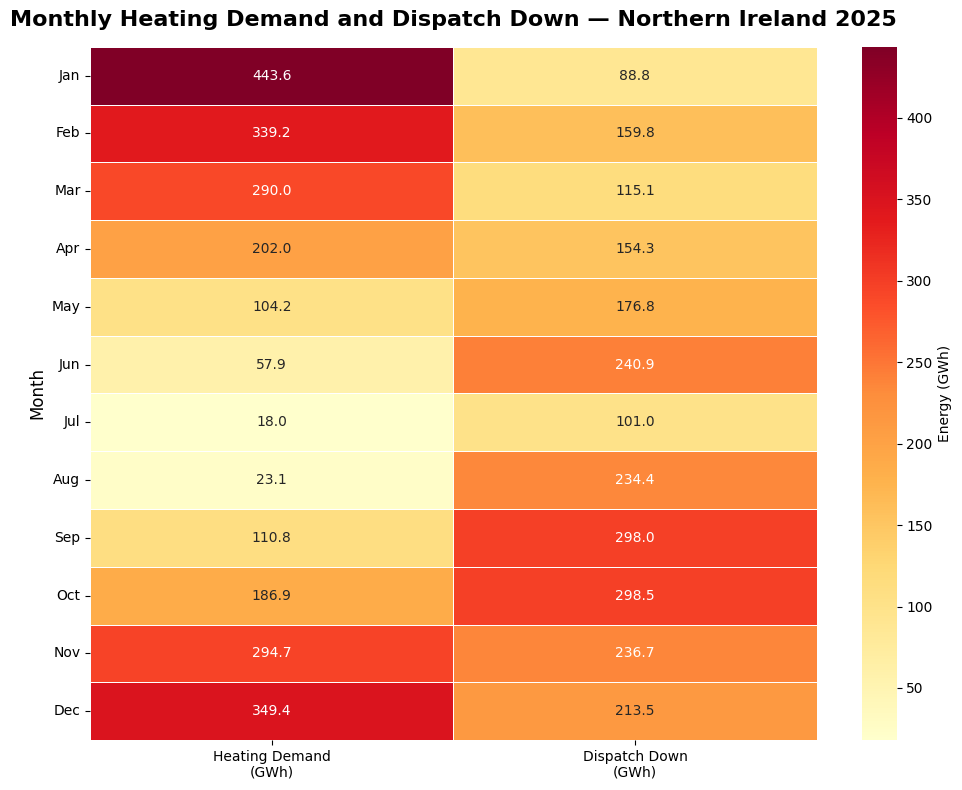

Saved: Dissertation_Figures_2025/Figure_1_Heating_Demand_vs_Dispatch_Down.png


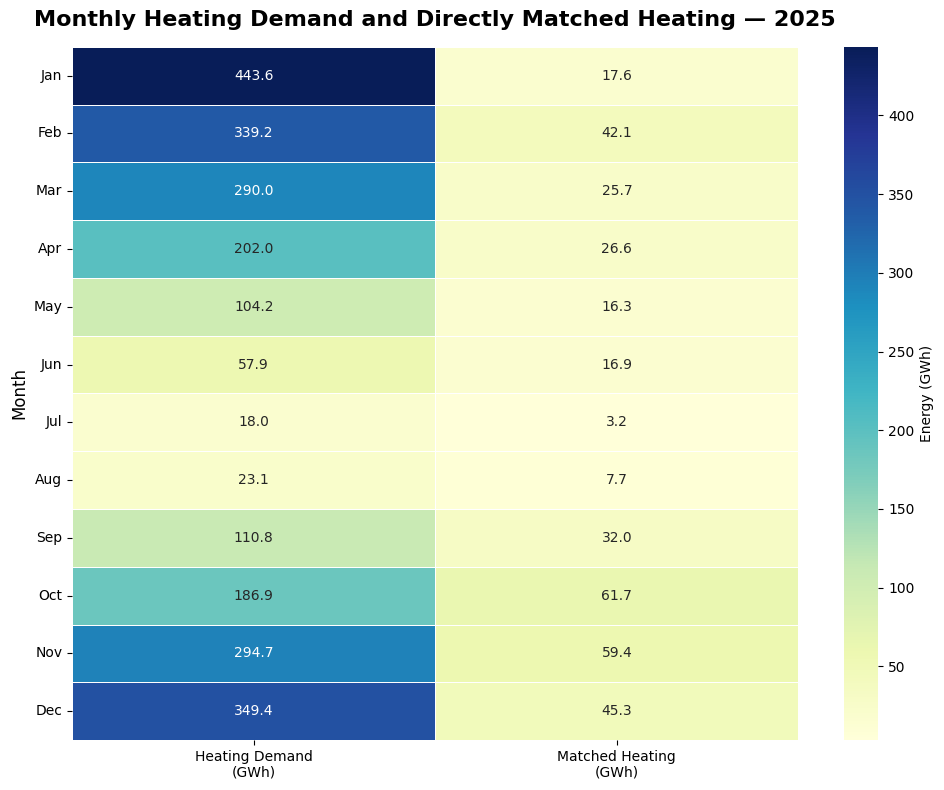

Saved: Dissertation_Figures_2025/Figure_2_Heating_Demand_vs_Matched.png


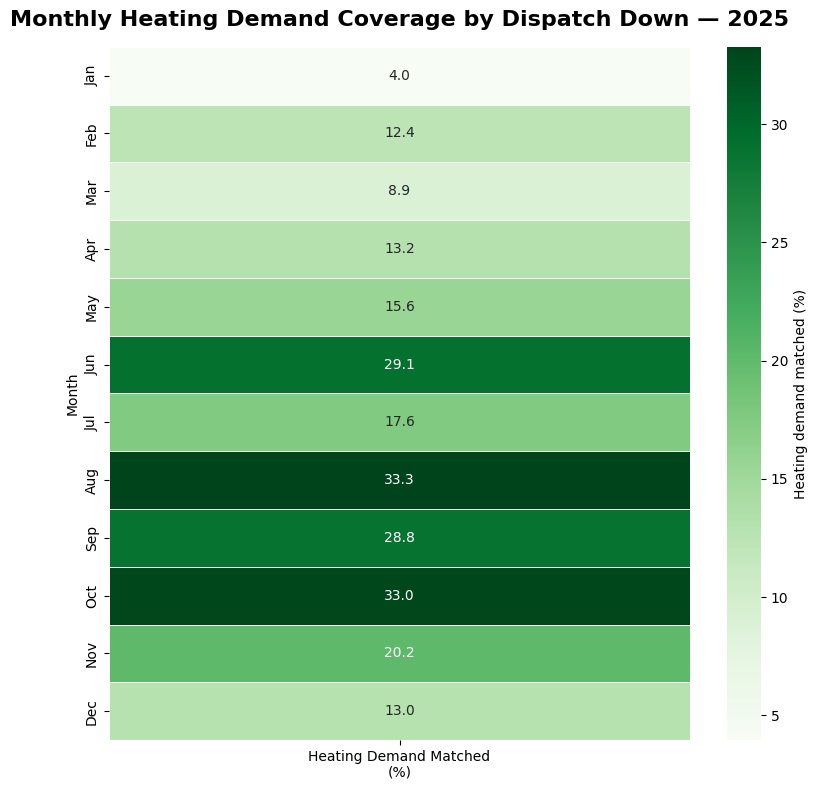

Saved: Dissertation_Figures_2025/Figure_3_Heating_Demand_Coverage.png


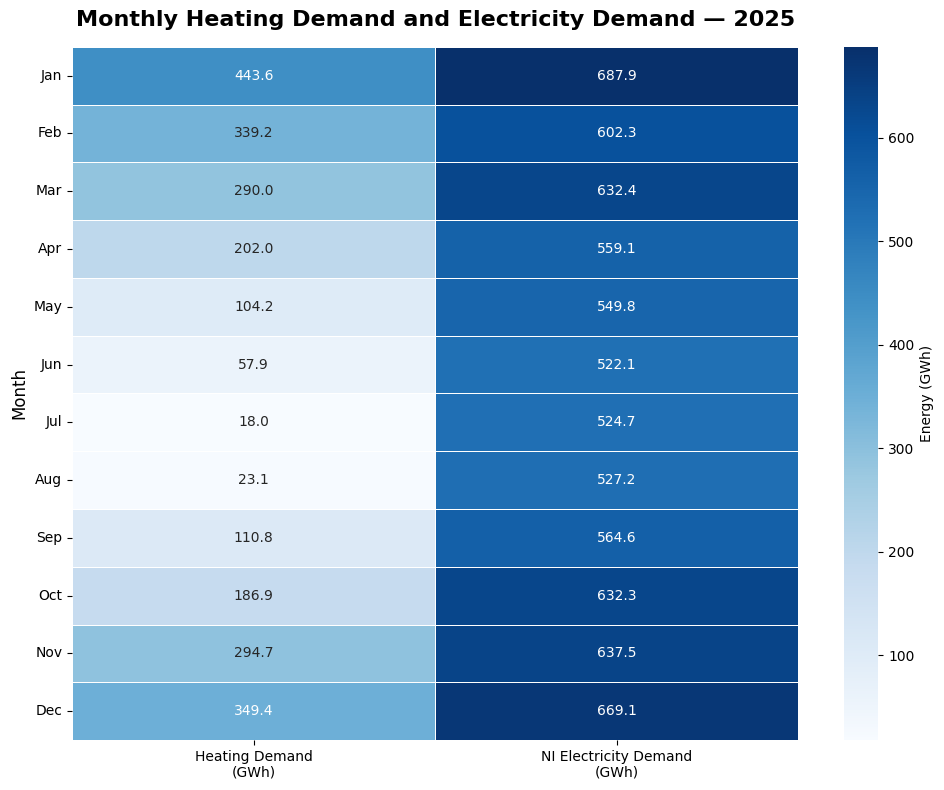

Saved: Dissertation_Figures_2025/Figure_4_Heating_Demand_vs_Electricity.png


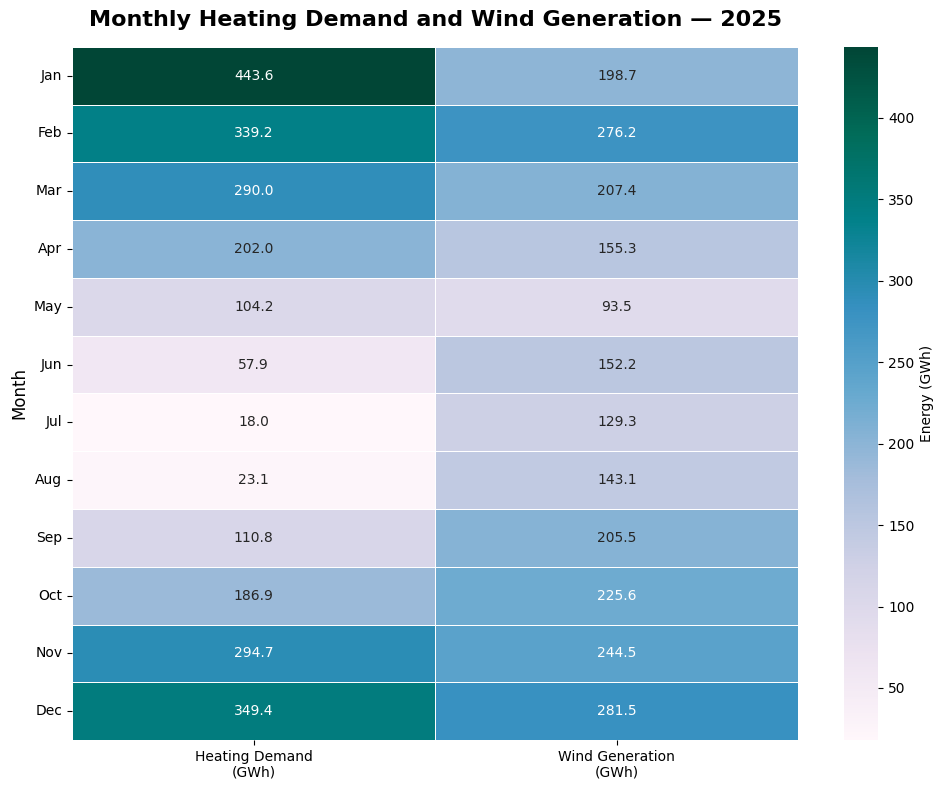

Saved: Dissertation_Figures_2025/Figure_5_Heating_Demand_vs_Wind.png


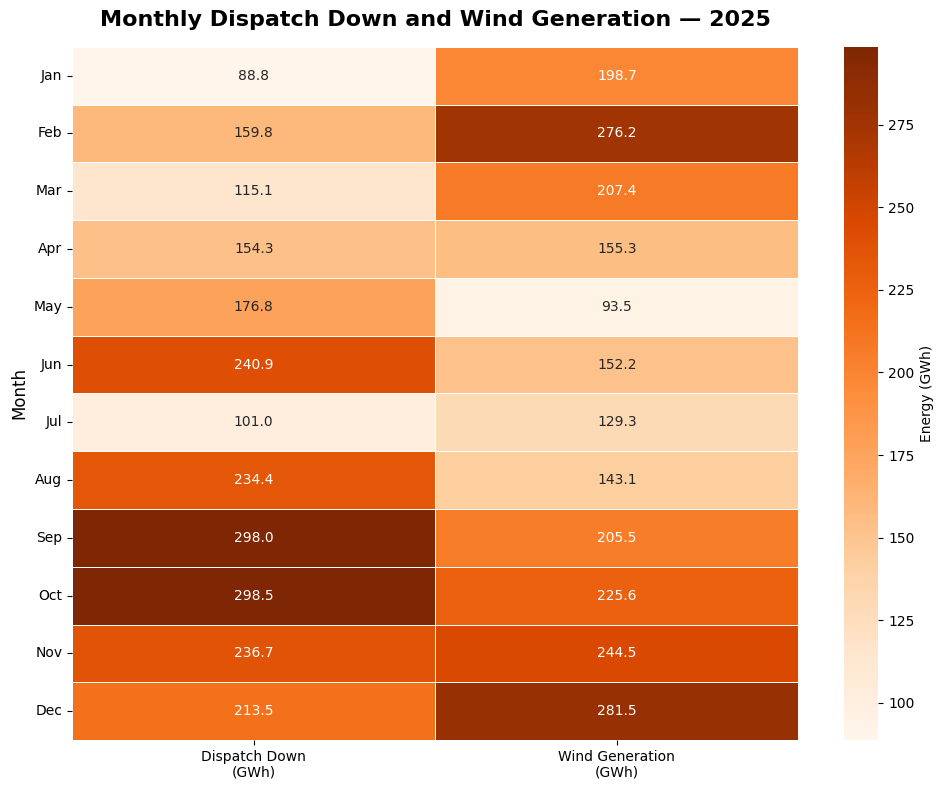

Saved: Dissertation_Figures_2025/Figure_6_Dispatch_Down_vs_Wind.png


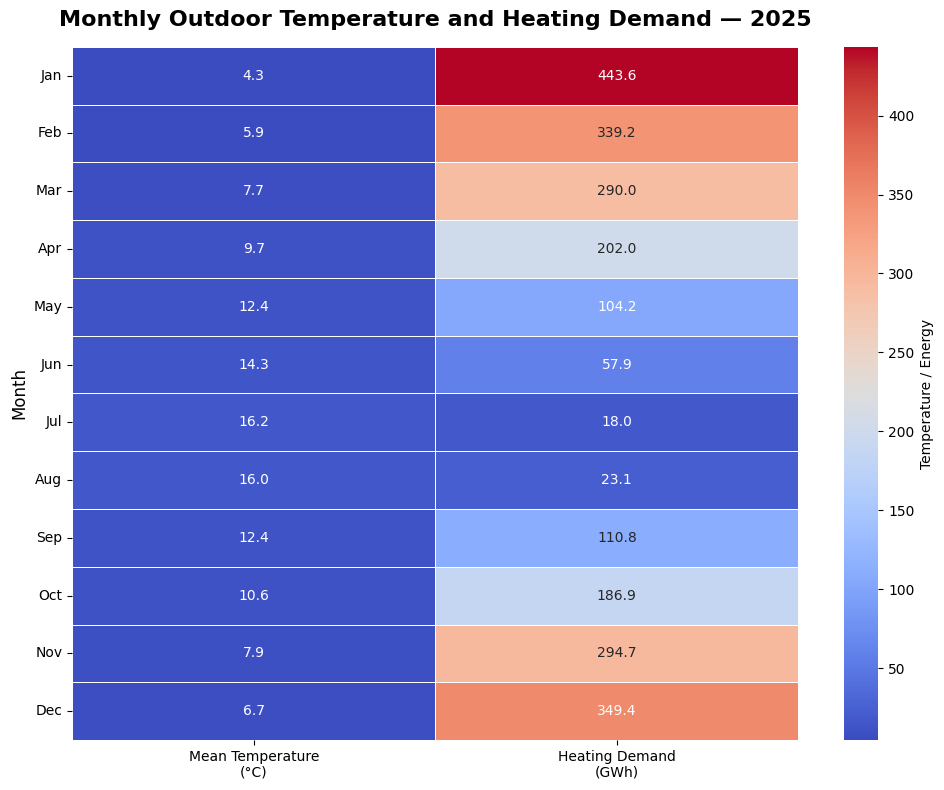

Saved: Dissertation_Figures_2025/Figure_7_Temperature_vs_Heating.png


CURTAILMENT / CONSTRAINT CHECK
Curtailment column: None
Constraint column: None

Figure 8 NOT generated.
Reason: separate curtailment and constraint columns were not found in the master dataset.
Do NOT create these values by assuming Dispatch Down = Curtailment.


ANALYSIS COMPLETE

All figures and results have been saved to:
Dissertation_Figures_2025

Monthly results file:
Dissertation_Figures_2025/Final_Monthly_Results_2025.xlsx

Generated files:
 - Figure_1_Heating_Demand_vs_Dispatch_Down.png
 - Figure_2_Heating_Demand_vs_Matched.png
 - Figure_3_Heating_Demand_Coverage.png
 - Figure_4_Heating_Demand_vs_Electricity.png
 - Figure_5_Heating_Demand_vs_Wind.png
 - Figure_6_Dispatch_Down_vs_Wind.png
 - Figure_7_Temperature_vs_Heating.png
 - Final_Monthly_Results_2025.xlsx


In [ ]:
# ================================================================
# MSc DISSERTATION
# NORTHERN IRELAND 2025
#
# FINAL MONTHLY HEAT-MAP AND RESULTS ANALYSIS
#
# Figures generated:
#
# Figure 1  - Heating Demand vs Dispatch Down
# Figure 2  - Heating Demand vs Matched Heating
# Figure 3  - Heating Demand Coverage (%)
# Figure 4  - Heating Demand vs Electricity Demand
# Figure 5  - Heating Demand vs Wind Generation
# Figure 6  - Dispatch Down vs Wind Generation
# Figure 7  - Temperature vs Heating Demand
# Figure 8  - Curtailment vs Constraint (ONLY if available)
# Figure 9  - 2-hour vs 4-hour matched heating
# Figure 10 - 2-hour vs 4-hour coverage
#
# All figures saved at 400 dpi.
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import files


# ================================================================
# 2. BASIC SETTINGS
# ================================================================

# Official number of NI households used in the dissertation
HOUSE_COUNT = 841827

# Duration of each dataset interval
INTERVAL_HOURS = 0.5

# Output folder
OUTPUT_FOLDER = "Dissertation_Figures_2025"

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)


# ================================================================
# 3. UPLOAD MASTER EXCEL FILE
# ================================================================

print("=" * 70)
print("UPLOAD YOUR MASTER 2025 EXCEL FILE")
print("=" * 70)

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("\nUploaded file:")
print(filename)


# ================================================================
# 4. SHOW AVAILABLE SHEETS
# ================================================================

excel_file = pd.ExcelFile(filename)

print("\nAvailable Excel sheets:")

for i, sheet in enumerate(excel_file.sheet_names):

    print(i, ":", sheet)


# ================================================================
# 5. FIND THE MASTER DATA SHEET
# ================================================================

selected_sheet = None
header_row = None

for sheet in excel_file.sheet_names:

    preview = pd.read_excel(
        filename,
        sheet_name=sheet,
        header=None,
        nrows=30
    )

    for r in range(len(preview)):

        row_text = " ".join(
            preview.iloc[r]
            .astype(str)
            .str.lower()
            .tolist()
        )

        if (
            "datetime" in row_text
            and "dispatch" in row_text
            and "heating" in row_text
        ):

            selected_sheet = sheet
            header_row = r

            break

    if selected_sheet is not None:
        break


if selected_sheet is None:

    raise ValueError(
        "The master data sheet could not be identified automatically."
    )


print("\nMaster data sheet:")
print(selected_sheet)

print(
    "Header row:",
    header_row + 1
)


# ================================================================
# 6. READ MASTER DATA
# ================================================================

df = pd.read_excel(
    filename,
    sheet_name=selected_sheet,
    header=header_row
)


# ================================================================
# 7. CLEAN COLUMN NAMES
# ================================================================

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace("\n", " ", regex=False)
)


print("\n" + "=" * 70)
print("COLUMNS IN MASTER DATASET")
print("=" * 70)

for col in df.columns:

    print(col)


# ================================================================
# 8. DATE/TIME
# ================================================================

# Use the exact DateTime column

if "DateTime" not in df.columns:

    # Try to identify it

    datetime_candidates = [
        c for c in df.columns
        if "datetime" in str(c).lower()
    ]

    if len(datetime_candidates) == 0:

        raise ValueError(
            "DateTime column could not be found."
        )

    datetime_col = datetime_candidates[0]

else:

    datetime_col = "DateTime"


df["DateTime"] = pd.to_datetime(
    df[datetime_col],
    errors="coerce"
)


df = df.dropna(
    subset=["DateTime"]
)


# ================================================================
# 9. KEEP ONLY 2025
# ================================================================

df = df[
    df["DateTime"].dt.year == 2025
].copy()


df = df.sort_values(
    "DateTime"
).reset_index(
    drop=True
)


print("\nNumber of 2025 rows:")
print(len(df))


print(
    "First timestamp:",
    df["DateTime"].min()
)

print(
    "Last timestamp:",
    df["DateTime"].max()
)


# ================================================================
# 10. DEFINE REQUIRED COLUMNS
# ================================================================

# ------------------------------------------------
# Heating
# ------------------------------------------------

HEATING_COLUMN = "Heating_Energy_Realistic_kWh"

if HEATING_COLUMN not in df.columns:

    raise ValueError(
        f"\n{HEATING_COLUMN} was not found.\n\n"
        "Available columns are:\n"
        + "\n".join(df.columns.astype(str))
    )


# ------------------------------------------------
# Dispatch Down
# ------------------------------------------------

DISPATCH_COLUMN = None

for col in df.columns:

    text = (
        str(col)
        .lower()
        .replace("_", "")
        .replace(" ", "")
    )

    if (
        "dispatch" in text
        and "down" in text
    ):

        DISPATCH_COLUMN = col
        break


if DISPATCH_COLUMN is None:

    raise ValueError(
        "Dispatch Down column could not be found."
    )


# ------------------------------------------------
# Temperature
# ------------------------------------------------

TEMPERATURE_COLUMN = None

for col in df.columns:

    text = str(col).lower()

    if "temperature" in text:

        TEMPERATURE_COLUMN = col
        break


# ------------------------------------------------
# Wind generation
# ------------------------------------------------

WIND_GENERATION_COLUMN = None

for col in df.columns:

    text = (
        str(col)
        .lower()
        .replace("_", "")
        .replace(" ", "")
    )

    if (
        "wind" in text
        and "generation" in text
    ):

        WIND_GENERATION_COLUMN = col
        break


# ------------------------------------------------
# NI electricity demand
# ------------------------------------------------

NI_DEMAND_COLUMN = None

for col in df.columns:

    text = (
        str(col)
        .lower()
        .replace("_", "")
        .replace(" ", "")
    )

    if (
        "nidemand" in text
        or text == "nidemand"
    ):

        NI_DEMAND_COLUMN = col
        break


print("\n" + "=" * 70)
print("SELECTED COLUMNS")
print("=" * 70)

print("Heating:")
print(HEATING_COLUMN)

print("\nDispatch Down:")
print(DISPATCH_COLUMN)

print("\nTemperature:")
print(TEMPERATURE_COLUMN)

print("\nWind Generation:")
print(WIND_GENERATION_COLUMN)

print("\nNI Electricity Demand:")
print(NI_DEMAND_COLUMN)


# ================================================================
# 11. CONVERT NUMERIC DATA
# ================================================================

df["Heating_Raw_kWh"] = pd.to_numeric(
    df[HEATING_COLUMN],
    errors="coerce"
)

df["Dispatch_Down_MWh"] = pd.to_numeric(
    df[DISPATCH_COLUMN],
    errors="coerce"
)


# ================================================================
# 12. SCALE HEATING DEMAND TO NI HOUSEHOLD STOCK
# ================================================================

# Heating_Energy_Realistic_kWh represents heating demand
# for one representative/reference dwelling.
#
# Total NI residential heating demand:
#
# Total heating demand =
# Reference-house heating demand × number of households
#
# Number of households = 841,827

df["Heating_Demand_kWh"] = (
    df["Heating_Raw_kWh"]
    * HOUSE_COUNT
)


# ================================================================
# 13. CALCULATE DIRECT MATCHING
# ================================================================

# Dispatch Down is system-level energy in MWh.
# Convert to kWh.

df["Dispatch_Down_kWh"] = (
    df["Dispatch_Down_MWh"]
    * 1000
)


# Heating that can be directly matched by
# Dispatch Down in the same 30-minute period

df["Matched_No_Flex_kWh"] = np.minimum(
    df["Heating_Demand_kWh"],
    df["Dispatch_Down_kWh"]
)


# ================================================================
# 14. MONTH
# ================================================================

df["Month"] = df["DateTime"].dt.month

months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec"
]

month_dictionary = dict(
    enumerate(
        months,
        start=1
    )
)


df["Month_Name"] = df["Month"].map(
    month_dictionary
)


# ================================================================
# 15. MONTHLY AGGREGATION
# ================================================================

monthly = df.groupby(
    "Month"
).agg({

    "Heating_Demand_kWh": "sum",

    "Dispatch_Down_MWh": "sum",

    "Matched_No_Flex_kWh": "sum"

}).reset_index()


monthly["Month_Name"] = monthly[
    "Month"
].map(
    month_dictionary
)


# ================================================================
# 16. CONVERT TO GWh
# ================================================================

monthly["Heating_Demand_GWh"] = (
    monthly["Heating_Demand_kWh"]
    / 1_000_000
)


monthly["Dispatch_Down_GWh"] = (
    monthly["Dispatch_Down_MWh"]
    / 1000
)


monthly["Matched_No_Flex_GWh"] = (
    monthly["Matched_No_Flex_kWh"]
    / 1_000_000
)


# ================================================================
# 17. HEATING DEMAND COVERAGE
# ================================================================

monthly["No_Flex_Coverage_%"] = (

    monthly["Matched_No_Flex_kWh"]
    /
    monthly["Heating_Demand_kWh"]
    *
    100

)


# ================================================================
# 18. 2-HOUR AND 4-HOUR FLEXIBILITY
# ================================================================

# Try to identify existing matched-energy columns.
#
# IMPORTANT:
# We use your existing flexibility results rather than
# rebuilding the storage algorithm here.

two_hour_column = None
four_hour_column = None


for col in df.columns:

    text = (
        str(col)
        .lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )

    if (
        "matched" in text
        and "2h" in text
    ):

        two_hour_column = col


    if (
        "matched" in text
        and "4h" in text
    ):

        four_hour_column = col


print("\nFlexibility columns detected:")

print(
    "2-hour:",
    two_hour_column
)

print(
    "4-hour:",
    four_hour_column
)


# ------------------------------------------------
# If existing columns are found
# ------------------------------------------------

if (
    two_hour_column is not None
    and four_hour_column is not None
):

    df["Matched_2h_kWh"] = pd.to_numeric(
        df[two_hour_column],
        errors="coerce"
    )

    df["Matched_4h_kWh"] = pd.to_numeric(
        df[four_hour_column],
        errors="coerce"
    )

    flex_monthly = df.groupby(
        "Month"
    ).agg({

        "Matched_2h_kWh": "sum",

        "Matched_4h_kWh": "sum"

    }).reset_index()


    flex_monthly["Month_Name"] = (
        flex_monthly["Month"]
        .map(month_dictionary)
    )


    flex_monthly["Matched_2h_GWh"] = (
        flex_monthly["Matched_2h_kWh"]
        / 1_000_000
    )


    flex_monthly["Matched_4h_GWh"] = (
        flex_monthly["Matched_4h_kWh"]
        / 1_000_000
    )


    flex_monthly = flex_monthly.merge(
        monthly[
            [
                "Month",
                "Heating_Demand_GWh"
            ]
        ],
        on="Month",
        how="left"
    )


    flex_monthly["2h_Coverage_%"] = (
        flex_monthly["Matched_2h_GWh"]
        /
        flex_monthly["Heating_Demand_GWh"]
        * 100
    )


    flex_monthly["4h_Coverage_%"] = (
        flex_monthly["Matched_4h_GWh"]
        /
        flex_monthly["Heating_Demand_GWh"]
        * 100
    )


else:

    flex_monthly = None

    print(
        "\nNOTE:"
        "\n2-hour/4-hour matched columns were not "
        "automatically detected."
        "\nThe flexibility figures will therefore "
        "not be generated from this cell."
    )


# ================================================================
# 19. WIND GENERATION
# ================================================================

if WIND_GENERATION_COLUMN is not None:

    df["Wind_Generation_MW"] = pd.to_numeric(
        df[WIND_GENERATION_COLUMN],
        errors="coerce"
    )

    # MW × 0.5 h = MWh

    df["Wind_Generation_MWh"] = (
        df["Wind_Generation_MW"]
        * INTERVAL_HOURS
    )


    wind_monthly = df.groupby(
        "Month"
    )["Wind_Generation_MWh"].sum()


    monthly["Wind_Generation_GWh"] = (
        monthly["Month"].map(
            wind_monthly
        )
        / 1000
    )


# ================================================================
# 20. NI ELECTRICITY DEMAND
# ================================================================

if NI_DEMAND_COLUMN is not None:

    df["NI_Demand_MW"] = pd.to_numeric(
        df[NI_DEMAND_COLUMN],
        errors="coerce"
    )

    # MW × 0.5 h = MWh

    df["NI_Demand_MWh"] = (
        df["NI_Demand_MW"]
        * INTERVAL_HOURS
    )


    demand_monthly = df.groupby(
        "Month"
    )["NI_Demand_MWh"].sum()


    monthly["NI_Electricity_Demand_GWh"] = (
        monthly["Month"].map(
            demand_monthly
        )
        / 1000
    )


# ================================================================
# 21. TEMPERATURE
# ================================================================

if TEMPERATURE_COLUMN is not None:

    df["Temperature_C"] = pd.to_numeric(
        df[TEMPERATURE_COLUMN],
        errors="coerce"
    )


    temperature_monthly = df.groupby(
        "Month"
    )["Temperature_C"].mean()


    monthly["Mean_Temperature_C"] = (
        monthly["Month"].map(
            temperature_monthly
        )
    )


# ================================================================
# 22. PRINT FINAL MONTHLY RESULTS
# ================================================================

print("\n")
print("=" * 90)
print("FINAL MONTHLY RESULTS — NORTHERN IRELAND 2025")
print("=" * 90)


print(
    monthly[
        [
            "Month_Name",
            "Heating_Demand_GWh",
            "Dispatch_Down_GWh",
            "Matched_No_Flex_GWh",
            "No_Flex_Coverage_%"
        ]
    ].round(2).to_string(index=False)
)


# ================================================================
# 23. PRINT ANNUAL RESULTS
# ================================================================

annual_heating = (
    monthly["Heating_Demand_GWh"].sum()
)

annual_dispatch = (
    monthly["Dispatch_Down_GWh"].sum()
)

annual_matched = (
    monthly["Matched_No_Flex_GWh"].sum()
)

annual_coverage = (
    annual_matched
    /
    annual_heating
    *
    100
)


print("\n")
print("=" * 70)
print("ANNUAL RESULTS")
print("=" * 70)

print(
    f"Annual heating demand     : "
    f"{annual_heating:,.2f} GWh"
)

print(
    f"Annual Dispatch Down      : "
    f"{annual_dispatch:,.2f} GWh"
)

print(
    f"No-flex matched heating   : "
    f"{annual_matched:,.2f} GWh"
)

print(
    f"No-flex heating coverage  : "
    f"{annual_coverage:.2f} %"
)


# ================================================================
# 24. HEATMAP FUNCTION
# ================================================================

def create_heatmap(
    data,
    columns,
    labels,
    title,
    colourmap,
    colourbar_label,
    filename
):

    heatmap_data = data[
        columns
    ].copy()


    heatmap_data.index = months


    heatmap_data.columns = labels


    plt.figure(
        figsize=(10, 8)
    )


    sns.heatmap(

        heatmap_data,

        annot=True,

        fmt=".1f",

        cmap=colourmap,

        linewidths=0.7,

        linecolor="white",

        cbar_kws={
            "label": colourbar_label
        }

    )


    plt.title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=15
    )


    plt.xlabel("")

    plt.ylabel(
        "Month",
        fontsize=12
    )


    plt.xticks(
        rotation=0
    )

    plt.yticks(
        rotation=0
    )


    plt.tight_layout()


    filepath = os.path.join(
        OUTPUT_FOLDER,
        filename
    )


    plt.savefig(
        filepath,
        dpi=400,
        bbox_inches="tight"
    )


    plt.show()


    print(
        "Saved:",
        filepath
    )


# ================================================================
# FIGURE 1
# HEATING DEMAND VS DISPATCH DOWN
# ================================================================

create_heatmap(

    monthly.set_index(
        "Month_Name"
    ),

    [
        "Heating_Demand_GWh",
        "Dispatch_Down_GWh"
    ],

    [
        "Heating Demand\n(GWh)",
        "Dispatch Down\n(GWh)"
    ],

    "Monthly Heating Demand and Dispatch Down — Northern Ireland 2025",

    "YlOrRd",

    "Energy (GWh)",

    "Figure_1_Heating_Demand_vs_Dispatch_Down.png"

)


# ================================================================
# FIGURE 2
# HEATING DEMAND VS DIRECTLY MATCHED HEATING
# ================================================================

create_heatmap(

    monthly.set_index(
        "Month_Name"
    ),

    [
        "Heating_Demand_GWh",
        "Matched_No_Flex_GWh"
    ],

    [
        "Heating Demand\n(GWh)",
        "Matched Heating\n(GWh)"
    ],

    "Monthly Heating Demand and Directly Matched Heating — 2025",

    "YlGnBu",

    "Energy (GWh)",

    "Figure_2_Heating_Demand_vs_Matched.png"

)


# ================================================================
# FIGURE 3
# HEATING DEMAND COVERAGE
# ================================================================

coverage = monthly[
    [
        "No_Flex_Coverage_%"
    ]
].copy()


coverage.index = months


coverage.columns = [
    "Heating Demand Matched\n(%)"
]


plt.figure(
    figsize=(8, 8)
)


sns.heatmap(

    coverage,

    annot=True,

    fmt=".1f",

    cmap="Greens",

    linewidths=0.7,

    linecolor="white",

    cbar_kws={
        "label":
        "Heating demand matched (%)"
    }

)


plt.title(
    "Monthly Heating Demand Coverage by Dispatch Down — 2025",
    fontsize=16,
    fontweight="bold",
    pad=15
)


plt.xlabel("")

plt.ylabel("Month")

plt.tight_layout()


filepath = os.path.join(
    OUTPUT_FOLDER,
    "Figure_3_Heating_Demand_Coverage.png"
)


plt.savefig(
    filepath,
    dpi=400,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    filepath
)


# ================================================================
# FIGURE 4
# HEATING DEMAND VS ELECTRICITY DEMAND
# ================================================================

if "NI_Electricity_Demand_GWh" in monthly.columns:

    create_heatmap(

        monthly.set_index(
            "Month_Name"
        ),

        [
            "Heating_Demand_GWh",
            "NI_Electricity_Demand_GWh"
        ],

        [
            "Heating Demand\n(GWh)",
            "NI Electricity Demand\n(GWh)"
        ],

        "Monthly Heating Demand and Electricity Demand — 2025",

        "Blues",

        "Energy (GWh)",

        "Figure_4_Heating_Demand_vs_Electricity.png"

    )


else:

    print(
        "\nFigure 4 skipped — NI electricity demand "
        "column not detected."
    )


# ================================================================
# FIGURE 5
# HEATING DEMAND VS WIND GENERATION
# ================================================================

if "Wind_Generation_GWh" in monthly.columns:

    create_heatmap(

        monthly.set_index(
            "Month_Name"
        ),

        [
            "Heating_Demand_GWh",
            "Wind_Generation_GWh"
        ],

        [
            "Heating Demand\n(GWh)",
            "Wind Generation\n(GWh)"
        ],

        "Monthly Heating Demand and Wind Generation — 2025",

        "PuBuGn",

        "Energy (GWh)",

        "Figure_5_Heating_Demand_vs_Wind.png"

    )


else:

    print(
        "\nFigure 5 skipped — wind generation "
        "column not detected."
    )


# ================================================================
# FIGURE 6
# DISPATCH DOWN VS WIND GENERATION
# ================================================================

if "Wind_Generation_GWh" in monthly.columns:

    create_heatmap(

        monthly.set_index(
            "Month_Name"
        ),

        [
            "Dispatch_Down_GWh",
            "Wind_Generation_GWh"
        ],

        [
            "Dispatch Down\n(GWh)",
            "Wind Generation\n(GWh)"
        ],

        "Monthly Dispatch Down and Wind Generation — 2025",

        "Oranges",

        "Energy (GWh)",

        "Figure_6_Dispatch_Down_vs_Wind.png"

    )


# ================================================================
# FIGURE 7
# TEMPERATURE VS HEATING DEMAND
# ================================================================

if "Mean_Temperature_C" in monthly.columns:

    create_heatmap(

        monthly.set_index(
            "Month_Name"
        ),

        [
            "Mean_Temperature_C",
            "Heating_Demand_GWh"
        ],

        [
            "Mean Temperature\n(°C)",
            "Heating Demand\n(GWh)"
        ],

        "Monthly Outdoor Temperature and Heating Demand — 2025",

        "coolwarm",

        "Temperature / Energy",

        "Figure_7_Temperature_vs_Heating.png"

    )


# ================================================================
# FIGURE 8
# CURTAILMENT VS CONSTRAINT
#
# ONLY GENERATED IF SEPARATE DATA COLUMNS EXIST.
# ================================================================

curtailment_column = None
constraint_column = None


for col in df.columns:

    text = (
        str(col)
        .lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )


    if (
        "curtail" in text
        and "constraint" not in text
    ):

        curtailment_column = col


    if "constraint" in text:

        constraint_column = col


print("\n")
print("=" * 70)
print("CURTAILMENT / CONSTRAINT CHECK")
print("=" * 70)

print(
    "Curtailment column:",
    curtailment_column
)

print(
    "Constraint column:",
    constraint_column
)


if (
    curtailment_column is not None
    and constraint_column is not None
):

    df["Curtailment_MWh"] = pd.to_numeric(
        df[curtailment_column],
        errors="coerce"
    )


    df["Constraint_MWh"] = pd.to_numeric(
        df[constraint_column],
        errors="coerce"
    )


    cc_monthly = df.groupby(
        "Month"
    ).agg({

        "Curtailment_MWh": "sum",

        "Constraint_MWh": "sum"

    }).reset_index()


    cc_monthly["Curtailment_GWh"] = (
        cc_monthly["Curtailment_MWh"]
        / 1000
    )


    cc_monthly["Constraint_GWh"] = (
        cc_monthly["Constraint_MWh"]
        / 1000
    )


    cc_monthly["Month_Name"] = (
        cc_monthly["Month"]
        .map(month_dictionary)
    )


    create_heatmap(

        cc_monthly.set_index(
            "Month_Name"
        ),

        [
            "Curtailment_GWh",
            "Constraint_GWh"
        ],

        [
            "Curtailment\n(GWh)",
            "Constraint\n(GWh)"
        ],

        "Monthly Curtailment and Constraint — Northern Ireland 2025",

        "PuBu",

        "Energy (GWh)",

        "Figure_8_Curtailment_vs_Constraint.png"

    )


else:

    print(
        "\nFigure 8 NOT generated."
    )

    print(
        "Reason: separate curtailment and constraint "
        "columns were not found in the master dataset."
    )

    print(
        "Do NOT create these values by assuming "
        "Dispatch Down = Curtailment."
    )


# ================================================================
# FIGURE 9
# 2-HOUR VS 4-HOUR MATCHED HEATING
# ================================================================

if flex_monthly is not None:

    flex_plot = flex_monthly.set_index(
        "Month_Name"
    )


    create_heatmap(

        flex_plot,

        [
            "Matched_2h_GWh",
            "Matched_4h_GWh"
        ],

        [
            "2-hour flexibility\n(GWh)",
            "4-hour flexibility\n(GWh)"
        ],

        "Monthly Heating Energy Matched Under Thermal Flexibility — 2025",

        "YlGn",

        "Matched heating energy (GWh)",

        "Figure_9_2h_vs_4h_Matched.png"

    )


# ================================================================
# FIGURE 10
# 2-HOUR VS 4-HOUR COVERAGE
# ================================================================

if flex_monthly is not None:

    coverage_flex = flex_monthly[
        [
            "2h_Coverage_%",
            "4h_Coverage_%"
        ]
    ].copy()


    coverage_flex.index = months


    coverage_flex.columns = [
        "2-hour flexibility\n(%)",
        "4-hour flexibility\n(%)"
    ]


    plt.figure(
        figsize=(10, 8)
    )


    sns.heatmap(

        coverage_flex,

        annot=True,

        fmt=".1f",

        cmap="Greens",

        linewidths=0.7,

        linecolor="white",

        cbar_kws={
            "label":
            "Heating demand coverage (%)"
        }

    )


    plt.title(
        "Monthly Heating Demand Coverage Under Thermal Flexibility — 2025",
        fontsize=16,
        fontweight="bold",
        pad=15
    )


    plt.xlabel("")

    plt.ylabel("Month")

    plt.tight_layout()


    filepath = os.path.join(
        OUTPUT_FOLDER,
        "Figure_10_2h_vs_4h_Coverage.png"
    )


    plt.savefig(
        filepath,
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        filepath
    )


# ================================================================
# 25. FINAL FLEXIBILITY SUMMARY
# ================================================================

if flex_monthly is not None:

    annual_2h = (
        flex_monthly[
            "Matched_2h_GWh"
        ].sum()
    )


    annual_4h = (
        flex_monthly[
            "Matched_4h_GWh"
        ].sum()
    )


    coverage_2h = (
        annual_2h
        /
        annual_heating
        *
        100
    )


    coverage_4h = (
        annual_4h
        /
        annual_heating
        *
        100
    )


    print("\n")
    print("=" * 70)
    print("THERMAL FLEXIBILITY RESULTS")
    print("=" * 70)


    print(
        f"Annual heating demand      : "
        f"{annual_heating:,.2f} GWh"
    )


    print(
        f"\nNo flexibility:"
    )

    print(
        f"Matched heating            : "
        f"{annual_matched:,.2f} GWh"
    )

    print(
        f"Coverage                   : "
        f"{annual_coverage:.2f} %"
    )


    print(
        f"\n2-hour pre-heating:"
    )

    print(
        f"Matched heating            : "
        f"{annual_2h:,.2f} GWh"
    )

    print(
        f"Coverage                   : "
        f"{coverage_2h:.2f} %"
    )

    print(
        f"Additional matched         : "
        f"{annual_2h - annual_matched:,.2f} GWh"
    )


    print(
        f"\n4-hour pre-heating:"
    )

    print(
        f"Matched heating            : "
        f"{annual_4h:,.2f} GWh"
    )

    print(
        f"Coverage                   : "
        f"{coverage_4h:.2f} %"
    )

    print(
        f"Additional matched         : "
        f"{annual_4h - annual_matched:,.2f} GWh"
    )


# ================================================================
# 26. SAVE MONTHLY RESULTS TO EXCEL
# ================================================================

results_file = os.path.join(
    OUTPUT_FOLDER,
    "Final_Monthly_Results_2025.xlsx"
)


monthly.to_excel(
    results_file,
    index=False
)


print("\n")
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print(
    "\nAll figures and results have been saved to:"
)

print(
    OUTPUT_FOLDER
)

print(
    "\nMonthly results file:"
)

print(
    results_file
)


# ================================================================
# 27. LIST OUTPUT FILES
# ================================================================

print("\nGenerated files:")

for file in sorted(
    os.listdir(OUTPUT_FOLDER)
):

    print(
        " -",
        file
    )

In [ ]:
# ============================================================
# STEP 1: UPLOAD AND CHECK THE ORIGINAL DISPATCH DOWN DATA
# MSc Dissertation - 2025 Northern Ireland Analysis
# ============================================================

import pandas as pd
from google.colab import files

# ------------------------------------------------------------
# 1. Upload the original Excel workbook
# ------------------------------------------------------------

print("Please upload the ORIGINAL Excel workbook used for your dissertation.")
uploaded = files.upload()

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

print("\nUploaded file:")
print(filename)

# ------------------------------------------------------------
# 2. Display all worksheet names
# ------------------------------------------------------------

excel_file = pd.ExcelFile(filename)

print("\nWorksheet names:")
for sheet in excel_file.sheet_names:
    print(" -", sheet)

# ------------------------------------------------------------
# 3. Find the Dispatch Down worksheet
# ------------------------------------------------------------

possible_sheets = [
    "DD_2025",
    "Dispatch Down",
    "Dispatch_Down",
    "DD 2025"
]

dd_sheet = None

for sheet in possible_sheets:
    if sheet in excel_file.sheet_names:
        dd_sheet = sheet
        break

if dd_sheet is None:
    print("\nWARNING: A Dispatch Down worksheet could not be identified automatically.")
    print("Please check the worksheet names printed above.")
else:

    print("\nDispatch Down worksheet found:")
    print(dd_sheet)

    # --------------------------------------------------------
    # 4. Read Dispatch Down data
    # --------------------------------------------------------

    dd = pd.read_excel(
        filename,
        sheet_name=dd_sheet
    )

    print("\nColumns in Dispatch Down worksheet:")
    print(dd.columns.tolist())

    # --------------------------------------------------------
    # 5. Display first and last rows
    # --------------------------------------------------------

    print("\nFIRST 10 ROWS:")
    display(dd.head(10))

    print("\nLAST 10 ROWS:")
    display(dd.tail(10))

    # --------------------------------------------------------
    # 6. Basic dataset information
    # --------------------------------------------------------

    print("\nDATASET INFORMATION")
    print("-------------------")

    print("Number of rows:", len(dd))
    print("Number of columns:", len(dd.columns))

    # --------------------------------------------------------
    # 7. Check for the expected columns
    # --------------------------------------------------------

    timestamp_col = None
    dispatch_col = None

    for col in dd.columns:
        col_clean = str(col).strip().lower()

        if "timestamp" in col_clean or "datetime" in col_clean:
            timestamp_col = col

        if "dd_mwh" in col_clean or "dispatch down" in col_clean:
            dispatch_col = col

    print("\nDetected timestamp column:", timestamp_col)
    print("Detected Dispatch Down column:", dispatch_col)

    # --------------------------------------------------------
    # 8. Dispatch Down total
    # --------------------------------------------------------

    if dispatch_col is not None:

        dd[dispatch_col] = pd.to_numeric(
            dd[dispatch_col],
            errors="coerce"
        )

        total_mwh = dd[dispatch_col].sum()
        total_gwh = total_mwh / 1000

        print("\nDISPATCH DOWN TOTAL")
        print("-------------------")
        print(f"Total Dispatch Down = {total_mwh:,.2f} MWh")
        print(f"Total Dispatch Down = {total_gwh:,.2f} GWh")

    else:
        print("\nWARNING: Dispatch Down quantity column was not detected.")

    # --------------------------------------------------------
    # 9. Timestamp checks
    # --------------------------------------------------------

    if timestamp_col is not None:

        dd[timestamp_col] = pd.to_datetime(
            dd[timestamp_col],
            errors="coerce"
        )

        print("\nTIMESTAMP CHECK")
        print("---------------")
        print("First timestamp:", dd[timestamp_col].min())
        print("Last timestamp:", dd[timestamp_col].max())
        print("Unique timestamps:", dd[timestamp_col].nunique())
        print("Missing timestamps:", dd[timestamp_col].isna().sum())

        # Check duplicate timestamps
        duplicates = dd[timestamp_col].duplicated().sum()

        print("Duplicate timestamps:", duplicates)

        # Check half-hourly intervals
        sorted_times = (
            dd[timestamp_col]
            .dropna()
            .sort_values()
            .drop_duplicates()
        )

        intervals = sorted_times.diff().dropna()

        print("\nMost common time intervals:")
        print(intervals.value_counts().head(10))

    # --------------------------------------------------------
    # 10. Missing Dispatch Down values
    # --------------------------------------------------------

    if dispatch_col is not None:

        print("\nMISSING / ZERO CHECK")
        print("--------------------")

        print(
            "Missing Dispatch Down values:",
            dd[dispatch_col].isna().sum()
        )

        print(
            "Zero Dispatch Down values:",
            (dd[dispatch_col] == 0).sum()
        )

    # --------------------------------------------------------
    # 11. Annual summary
    # --------------------------------------------------------

    if dispatch_col is not None and timestamp_col is not None:

        dd["Month"] = dd[timestamp_col].dt.month

        monthly_dd = (
            dd.groupby("Month")[dispatch_col]
            .sum()
            .reset_index()
        )

        monthly_dd["Dispatch Down (GWh)"] = (
            monthly_dd[dispatch_col] / 1000
        )

        monthly_dd["Month"] = monthly_dd["Month"].map({
            1: "Jan",
            2: "Feb",
            3: "Mar",
            4: "Apr",
            5: "May",
            6: "Jun",
            7: "Jul",
            8: "Aug",
            9: "Sep",
            10: "Oct",
            11: "Nov",
            12: "Dec"
        })

        print("\nMONTHLY DISPATCH DOWN")
        print("---------------------")

        display(
            monthly_dd[
                ["Month", "Dispatch Down (GWh)"]
            ]
        )

# ============================================================
# END OF CHECK
# ============================================================

print("\n============================================================")
print("CHECK COMPLETE")
print("============================================================")
print("\nDo NOT change the Excel data yet.")
print("We first need to establish exactly what this Dispatch Down")
print("dataset represents before recalculating your dissertation.")

Please upload the ORIGINAL Excel workbook used for your dissertation.


Saving Excel Sheet.xlsx to Excel Sheet.xlsx

Uploaded file:
Excel Sheet.xlsx

Worksheet names:
 - DD_2025
 - DD_2025 Pivot(Monthly)
 - DD_2025 Pivot(Daily)
 - DD_2025 Pivot(HalfHourly)
 - DD_2025_Cumulative
 - DD_2025_Seasonal
 - DD_2025_Curtailment_vs_Constrai
 - DD_2025_Summary   
 - DD_2026
 - System_2025
 - System_2025_Monthly
 - 2025_Monthly_NI_Demand
 - 2025_Monthly_NI_WindGeneration
 - 2025_Monthly_NI_WindGen_pivot
 - 2025_Demand_vs_Wind
 - 2025_Monthly_NI_WindAvail
 - 2025_Monthly_Wind_Penetration
 - 2025_Curtailment_vs_Demand
 - 2025_Curtailment_vs_WindGen
 - 2025_Curtailment_vs_WindAvail
 - System_2026
 - Pivot
 - Charts
 - Calculations

Dispatch Down worksheet found:
DD_2025

Columns in Dispatch Down worksheet:
[' ', 'JURISDICTION', 'HH_TIMESTAMP', 'GMT_OFFSET', 'Sum of AV_MWH', 'Sum of AO_MWH', 'Sum of HI_FRQ_MIN_GEN_MWH', 'Sum of ROCOF_INERTIA_MWH', 'Sum of SNSP_MWH', 'Sum of TRANS_CONSTR_MWH', 'Sum of TSO_TEST_MWH', 'Sum of DD_MWH', 'Sum of CURTAILMENTS_MWH', 'Sum of CONS

,,JURISDICTION,HH_TIMESTAMP,GMT_OFFSET,Sum of AV_MWH,Sum of AO_MWH,Sum of HI_FRQ_MIN_GEN_MWH,Sum of ROCOF_INERTIA_MWH,Sum of SNSP_MWH,Sum of TRANS_CONSTR_MWH,Sum of TSO_TEST_MWH,Sum of DD_MWH,Sum of CURTAILMENTS_MWH,Sum of CONSTRAINTS_MWH,Sum of OTHER_MWH
0,Wind,IE,2025-01-01 00:00:00,0,1215.962,952.922,174.937,0.0,0.0,72.958,0.0,247.895,174.937,72.958,0.0
1,Wind,IE,2025-01-01 00:30:00,0,1277.066,1024.962,158.570,0.0,0.0,81.557,0.0,240.129,158.570,81.557,0.0
2,Wind,IE,2025-01-01 01:00:00,0,1292.572,986.649,201.153,0.0,0.0,78.621,0.0,279.769,201.153,78.621,0.0
3,Wind,IE,2025-01-01 01:30:00,0,1349.876,945.285,296.972,0.0,0.0,86.617,0.0,383.588,296.972,86.617,0.0
4,Wind,IE,2025-01-01 02:00:00,0,1397.604,932.533,345.545,0.0,0.0,91.469,0.0,437.012,345.545,91.469,0.0
5,Wind,IE,2025-01-01 02:30:00,0,1326.277,896.719,327.188,0.0,0.0,81.768,0.0,408.956,327.188,81.768,0.0
6,Wind,IE,2025-01-01 03:00:00,0,1223.563,868.130,292.176,0.0,0.0,50.015,0.0,342.194,292.176,50.015,0.0
7,Wind,IE,2025-01-01 03:30:00,0,1157.625,818.321,279.148,0.0,0.0,33.856,0.0,313.007,279.148,33.856,0.0
8,Wind,IE,2025-01-01 04:00:00,0,1218.412,782.022,403.221,0.0,0.0,22.851,0.0,426.070,403.221,22.851,0.0
9,Wind,IE,2025-01-01 04:30:00,0,1261.574,744.210,462.700,0.0,0.0,29.716,0.0,492.411,462.700,29.716,0.0



LAST 10 ROWS:


,,JURISDICTION,HH_TIMESTAMP,GMT_OFFSET,Sum of AV_MWH,Sum of AO_MWH,Sum of HI_FRQ_MIN_GEN_MWH,Sum of ROCOF_INERTIA_MWH,Sum of SNSP_MWH,Sum of TRANS_CONSTR_MWH,Sum of TSO_TEST_MWH,Sum of DD_MWH,Sum of CURTAILMENTS_MWH,Sum of CONSTRAINTS_MWH,Sum of OTHER_MWH
70070,Solar,NI,2025-12-31 19:00:00,0,0.285,0.0,0.0,0.0,0.0,0.038,0.0,0.038,0.0,0.038,0.0
70071,Solar,NI,2025-12-31 19:30:00,0,0.791,0.0,0.0,0.0,0.0,0.118,0.0,0.118,0.0,0.118,0.0
70072,Solar,NI,2025-12-31 20:00:00,0,0.791,0.0,0.0,0.0,0.0,0.164,0.0,0.164,0.0,0.164,0.0
70073,Solar,NI,2025-12-31 20:30:00,0,0.791,0.0,0.0,0.0,0.0,0.192,0.0,0.192,0.0,0.192,0.0
70074,Solar,NI,2025-12-31 21:00:00,0,0.791,0.0,0.0,0.0,0.0,0.271,0.0,0.271,0.0,0.271,0.0
70075,Solar,NI,2025-12-31 21:30:00,0,0.791,0.0,0.0,0.0,0.0,0.282,0.0,0.282,0.0,0.282,0.0
70076,Solar,NI,2025-12-31 22:00:00,0,0.791,0.0,0.0,0.0,0.0,0.380,0.0,0.380,0.0,0.380,0.0
70077,Solar,NI,2025-12-31 22:30:00,0,0.791,0.0,0.0,0.0,0.0,0.550,0.0,0.550,0.0,0.550,0.0
70078,Solar,NI,2025-12-31 23:00:00,0,0.791,0.0,0.0,0.0,0.0,0.579,0.0,0.579,0.0,0.579,0.0
70079,Solar,NI,2025-12-31 23:30:00,0,0.791,0.0,0.0,0.0,0.0,0.642,0.0,0.642,0.0,0.642,0.0



DATASET INFORMATION
-------------------
Number of rows: 70080
Number of columns: 15

Detected timestamp column: HH_TIMESTAMP
Detected Dispatch Down column: Sum of DD_MWH

DISPATCH DOWN TOTAL
-------------------
Total Dispatch Down = 2,316,841.34 MWh
Total Dispatch Down = 2,316.84 GWh

TIMESTAMP CHECK
---------------
First timestamp: 2025-01-01 00:00:00
Last timestamp: 2025-12-31 23:30:00
Unique timestamps: 17518
Missing timestamps: 0
Duplicate timestamps: 52562

Most common time intervals:
HH_TIMESTAMP
0 days 00:30:00    17516
0 days 01:30:00        1
Name: count, dtype: int64

MISSING / ZERO CHECK
--------------------
Missing Dispatch Down values: 0
Zero Dispatch Down values: 37923

MONTHLY DISPATCH DOWN
---------------------


,Month,Dispatch Down (GWh)
0,Jan,88.764003
1,Feb,159.792579
2,Mar,115.127176
3,Apr,154.285188
4,May,176.751467
5,Jun,240.885551
6,Jul,100.955939
7,Aug,234.442711
8,Sep,298.024193
9,Oct,297.617805



CHECK COMPLETE

Do NOT change the Excel data yet.
We first need to establish exactly what this Dispatch Down
dataset represents before recalculating your dissertation.
